In [1]:
!pip install -r requirements.txt



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


# 1. Entendimento do Negócio (Business Understanding)

## 1.1 Contexto do Problema

Reincidência criminal é um desafio crítico do sistema de justiça criminal. A capacidade de prever com precisão quais indivíduos têm maior probabilidade de recindir após libertação é essencial para:

- **Alocação de recursos**: Direcionar programas de reabilitação e supervisão para indivíduos de alto risco
- **Tomada de decisões judiciais**: Auxiliar em decisões de condicional, liberdade supervisionada e prisão preventiva
- **Redução de crimes**: Minimizar danos à comunidade através de intervenções direcionadas
- **Equidade no sistema**: Identificar fatores que influenciam reincidência e possíveis vieses

## 1.2 Pergunta de Negócio

**Quais características demográficas, penais e comportamentais são mais indicativas de reincidência criminal nos 3 anos seguintes à libertação?**

## 1.3 Objetivos do Projeto

### Objetivo Principal
Desenvolver um modelo preditivo que identifique indivíduos com alto risco de reincidência nos 3 anos seguintes à libertação, com acurácia e recall balanceados.

### Objetivos Secundários
1. Identificar os fatores mais influentes na reincidência
2. Criar um sistema de classificação binária de predição de reincidência
3. Avaliar a performance do modelo em dados
4. Documentar insights acionáveis para políticas de justiça criminal

## 1.4 Definição Operacional da Variável Alvo

**Reincidência Criminal**: Prisão comprovada dentro de 3 anos após a libertação inicial

- **Classe Positiva (1)**: Indivíduo reincidiu (foi preso novamente)
- **Classe Negativa (0)**: Indivíduo não reincidiu

## 1.5 Dataset e Dados Disponíveis

**Fonte**: NIJ (National Institute of Justice) Challenge 2021
- **Período**: Dados históricos de detentos e suas trajetórias
- **Tamanho**: cerca de 25.000 registros
- **Features**: 54 variáveis (demográficas, histórico penal, comportamento, etc.)

### Tipos de Dados Disponíveis
- **Demográficos**: Idade, gênero, raça, estado civil
- **Histórico Penal**: Crimes anteriores, violações, condicionais
- **Comportamento**: Testes de droga, afiliação a gangues, violações de supervisão
- **Emprego e Residência**: Taxa de emprego, mudanças de residência
- **Programas**: Participação em programas educacionais e de tratamento

## 1.6 Critérios de Sucesso

### Critérios Técnicos
| Métrica | Alvo | Justificativa |
|---------|------|---------------|
| **Acurácia** | > 70% | Classificação geral correta |
| **AUC-ROC** | > 0.75 | Discriminação entre classes |
| **Recall (Sensibilidade)** | > 80% | Capturar a maioria dos reincidentes |
| **Precisão** | > 65% | Minimizar falsos positivos (injustiça) |

### Critérios de Negócio
- Identificar features acionáveis para intervenção
- Criar ranking de fatores de risco
- Modelo interpretável para stakeholders (não caixa preta)
- Documentação clara para implementação

## 1.7 Stakeholders Envolvidos

| Stakeholder | Interesse | Necessidade |
|-------------|-----------|------------|
| **Departamento de Justiça** | Reduzir reincidência | Modelo confiável e justificável |
| **Juízes e Promotores** | Decisões informadas | Avaliação de risco para cada caso |
| **Programas de Reabilitação** | Alocação de recursos | Identificar quem precisa mais |
| **Supervisão de Condicional** | Monitoramento eficaz | Focar em alto risco |
| **Comunidade** | Segurança pública | Redução de crimes |

## 1.8 Limitações e Restrições

- **Dados históricos**: Modelo reflete padrões passados; possível viés replicado
- **Diferenças sociodemográficas**: Possível divergência em subgrupos (raça, gênero)
- **Mudanças contextuais**: Podem afetar validade do modelo ao longo do tempo
- **Privacidade**: Necessária conformidade com regulamentações de proteção de dados

## 1.9 Métricas Finais Esperadas

**Após modelagem, espera-se alcançar:**

- Identificação das **features principais** associadas a reincidência
- Modelo com métricas **AUC**, **Recall** e **Precisão** satisfatórias
- Matriz de confusão mostrando trade-off entre sensibilidade e especificidade
- Interpretação clara dos fatores de risco para audiência não técnica

#Dicionário de dados

ID = Identificação

Gender = Gênero, Sexo

Race = Raça

Age at Release = Idade na Liberação

Residence PUMA = Residência PUMA
Nota: As Áreas de Microdados de Uso Público (PUMAs, na sigla em inglês) são áreas geográficas estatísticas não sobrepostas que dividem cada estado ou entidade equivalente em áreas geográficas com, no mínimo, 100.000 habitantes cada. (https://usa.ipums.org/usa-action/variables/PUMA#description_section)

Gang Affiliated = Afiliação a Gangues

Supervision Risk Score First = Pontuação Máxima de Risco de Supervisão
Nota: As pontuações de risco de supervisão de presos são ferramentas baseadas em evidências e orientadas por dados, utilizadas para prever a probabilidade de reincidência (baixa, moderada, alta) e determinar os níveis de supervisão apropriados (por exemplo, a frequência das visitas dos agentes penitenciários). (https://www.uscourts.gov/about-federal-courts/probation-and-pretrial-services/evidence-based-practices/post-conviction-risk-assessment)

Supervision Level First = Nível de Supervisão 1
Nota: O nível de supervisão é um tipo de classificação. Ele divide os indivíduos em liberdade condicional e os liberados condicionalmente em subgrupos que compartilham a mesma intensidade de supervisão e frequência de contato. (https://equivant-supervision.com/risk-level-vs-supervision-level-common-misconceptions/#:~:text=Supervision%20level%20is%20a%20type,risk%20score%2C%20different%20supervision%20needs.)

Education Level = Nível de Escolaridade

Dependents = Dependentes

Prison Offense = Crime na Prisão

Prison Years = Anos de Prisão

Prior Arrest Episodes Felony = Episódios Anteriores de Prisão por Crime Grave

Prior Arrest Episodes Misd = Episódios Anteriores de Prisão por Contravenção

Prior Arrest Episodes Violent = Episódios Anteriores de Prisão por Crime Violento

Prior Arrest Episodes Property = Episódios Anteriores de Prisão por Crime Contra a Propriedade

Prior Arrest Episodes Drug = Episódios Anteriores de Prisão por Drogas

Prior Arrest Episodes DV Charges = Episódios Anteriores de Prisão por Acusações de Violência Doméstica

Prior Arrest Episodes Gun Charges = Episódios Anteriores de Prisão por Porte de Arma

Prior Conviction Episodes Felony = Episódios Anteriores de Condenação por Crime Grave

Prior Conviction Episodes Misd = Episódios Anteriores de Condenação por Contravenção

Prior Conviction Episodes Viol = Episódios Anteriores de Condenação por Crime Violento

Prior Conviction Episodes Prop = Episódios Anteriores de Condenação por Crime Contra a Propriedade

Prior Conviction Episodes Drug = Episódios Anteriores de Condenação por Drogas

Prior Revocations Parole= Revogações Anteriores de Liberdade Condicional

Prior Revocations Probation = Revogações Anteriores de Liberdade Provisória

Condition MH SA = Condição MH SA (problemas de saúde mental??)
Nota: MHSA refere-se ao Mental Health Services Act (https://www.dhcs.ca.gov/services/MH/Pages/MHSA-Components.aspx)

Condition Cog Ed = Condição Cog Ed (comprometimento cognitivo??)
Nota: A Tarefa de Desconto do Esforço Cognitivo (COG-ED) é um paradigma comportamental que mede como o esforço mental reduz o valor subjetivo de uma recompensa. (https://www.millisecond.com/library/cognitiveeffortdiscountingtask)

Condition Other = Condição Outra

Violations Electronic Monitoring = Violações de Monitoramento Eletrônico

Violations Instruction = Violações de Instrução

Violations Fail To Report = Violações de Não Comparecimento

Violations Move Without Permission = Violações de Mudança Sem Permissão

Delinquency Reports = Relatórios de Delinquência

Program Attendances = Frequências ao Programa

Program Unexcused Absences = Ausências Injustificadas ao Programa

Residence Changes = Mudanças de Residência

Avg Days per Drug Test = Média de Dias por Teste de Drogas

Drug Tests THC Positive = Testes de drogas: THC positivo
Nota: O THC é o principal composto psicoativo da planta cannabis (maconha), responsável pelos efeitos alucinógenos, euforia e relaxamento. (https://www.cremesp.org.br/pdfs/eventos/eve_07052018_193204_Diferenca%20entre%20o%20uso%20da%20Cannabis,%20canabidiol%20e%20THC%20-%20Amouni%20Mohmoud%20Mourad.pdf)

Drug Tests Cocaine Positive = Cocaína positivo

Drug Tests Meth Positive = Metanfetamina positivo

Drug Tests Other Positive = Outras drogas positivas

Percent Days Employed = Percentual de dias empregados

Jobs Per Year = Empregos por ano

Employment Exempt = Emprego Isento

Recidivism Within 3 years = Reincidência em 3 anos

Recidivism Arrest Year 1 = Ano da prisão por reincidência (1º ano) (não utilizada)

Recidivism Arrest Year 2 = Ano da prisão por reincidência (2º ano) (não utilizada)

Recidivism Arrest Year 3 = Ano da prisão por reincidência (3º ano) (não utilizada)

# 2. Entendimento dos Dados (Data Understanding)

Coleta, explora e verifica a qualidade dos dados disponíveis para identificar insights iniciais.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score,
                             roc_curve, accuracy_score)
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import _tree
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# Estilo dos gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'figure.figsize': (10, 5)})

ARQUIVO = 'nij-challenge2021_full_dataset.csv'
LABEL = 'Recidivism_Within_3years'
SEED = 42

In [3]:
df_raw = pd.read_csv(ARQUIVO)

print("=== VISÃO GERAL DOS DADOS BRUTOS ===")
print(f"Dimensões : {df_raw.shape[0]:,} registros x {df_raw.shape[1]} colunas")
print(f"\nPrimeiras linhas:")
df_raw.head(3)

=== VISÃO GERAL DOS DADOS BRUTOS ===
Dimensões : 25,835 registros x 54 colunas

Primeiras linhas:


,ID,Gender,Race,Age_at_Release,Residence_PUMA,Gang_Affiliated,Supervision_Risk_Score_First,Supervision_Level_First,Education_Level,Dependents,...,DrugTests_Meth_Positive,DrugTests_Other_Positive,Percent_Days_Employed,Jobs_Per_Year,Employment_Exempt,Recidivism_Within_3years,Recidivism_Arrest_Year1,Recidivism_Arrest_Year2,Recidivism_Arrest_Year3,Training_Sample
0,1,M,BLACK,43-47,16,No,3.0,Standard,At least some college,3 or more,...,0.000000,0.0,0.488562,0.44761,No,No,No,No,No,1
1,2,M,BLACK,33-37,16,No,6.0,Specialized,Less than HS diploma,1,...,0.000000,0.0,0.425234,2.00000,No,Yes,No,No,Yes,1
2,3,M,BLACK,48 or older,24,No,7.0,High,At least some college,3 or more,...,0.166667,0.0,0.000000,0.00000,No,Yes,No,Yes,No,1



VALORES AUSENTES
                              Ausentes  % do total
Avg_Days_per_DrugTest             6103       23.62
DrugTests_THC_Positive            5172       20.02
DrugTests_Cocaine_Positive        5172       20.02
DrugTests_Other_Positive          5172       20.02
DrugTests_Meth_Positive           5172       20.02
Prison_Offense                    3277       12.68
Gang_Affiliated                   3167       12.26
Supervision_Level_First           1720        6.66
Jobs_Per_Year                      808        3.13
Supervision_Risk_Score_First       475        1.84
Percent_Days_Employed              462        1.79


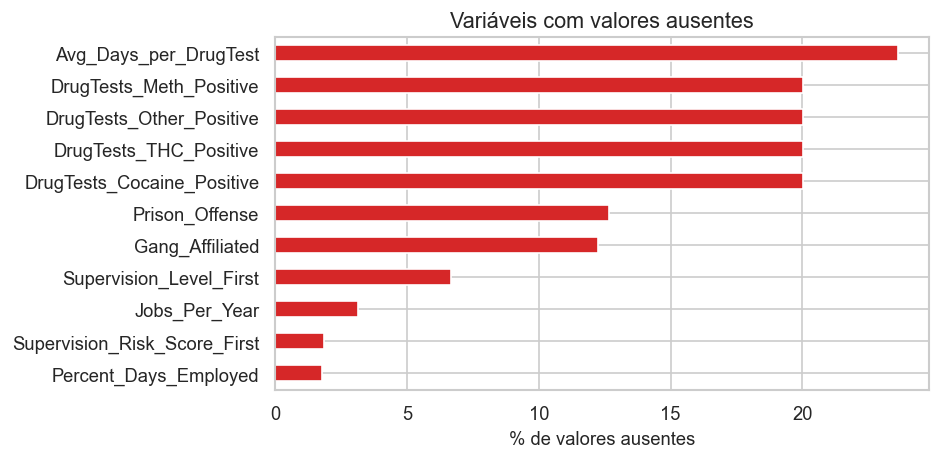

In [7]:
#print("TIPOS DE DADOS")
#print(df_raw.dtypes.to_string())

print("\nVALORES AUSENTES")
miss = df_raw.isnull().sum()
miss = miss[miss > 0].sort_values(ascending=False)
miss_pct = (miss / len(df_raw) * 100).round(2)
df_miss = pd.DataFrame({'Ausentes': miss, '% do total': miss_pct})
print(df_miss.to_string())

# Gráfico de valores ausentes
fig, ax = plt.subplots(figsize=(8, 4))
miss_pct.sort_values().plot(kind='barh', ax=ax, color='#d62728')
ax.set_xlabel('% de valores ausentes')
ax.set_title('Variáveis com valores ausentes')
plt.tight_layout()
plt.show()

In [8]:
# Colunas a remover
REMOVER = [
    'ID', # identificador sem valor preditivo
    'Training_Sample', # indicador de partição
    'Recidivism_Arrest_Year1', # evitar DATA LEAKAGE
    'Recidivism_Arrest_Year2', # evitar DATA LEAKAGE
    'Recidivism_Arrest_Year3', # evitar DATA LEAKAGE
    '_v1', '_v2', '_v3', '_v4', # colunas auxiliares sem semântica
    'Residence_PUMA', # código geográfico -> precisamos agregar mais informação para identificar o código de cada área
]

df = df_raw.drop(columns=REMOVER).copy()

# Converter label Yes/No -> 1/0
df[LABEL] = df[LABEL].map({'Yes': 1, 'No': 0}).astype(int)

# Mapeamento das variáveis ordinais (censored "X or more" -> inteiro)
MAPA_ORDINAIS = {
    'Prior_Arrest_Episodes_Felony':    {'0':0,'1':1,'2':2,'3':3,'4':4,'5':5,
                                        '6':6,'7':7,'8':8,'9':9,'10 or more':10},
    'Prior_Arrest_Episodes_Misd':      {'0':0,'1':1,'2':2,'3':3,'4':4,'5':5,
                                        '6 or more':6},
    'Prior_Arrest_Episodes_Violent':   {'0':0,'1':1,'2':2,'3 or more':3},
    'Prior_Arrest_Episodes_Property':  {'0':0,'1':1,'2':2,'3':3,'4':4,
                                        '5 or more':5},
    'Prior_Arrest_Episodes_Drug':      {'0':0,'1':1,'2':2,'3':3,'4':4,
                                        '5 or more':5},
    'Prior_Conviction_Episodes_Felony':{'0':0,'1':1,'2':2,'3 or more':3},
    'Prior_Conviction_Episodes_Misd':  {'0':0,'1':1,'2':2,'3':3,'4 or more':4},
    'Prior_Conviction_Episodes_Prop':  {'0':0,'1':1,'2':2,'3 or more':3},
    'Prior_Conviction_Episodes_Drug':  {'0':0,'1':1,'2 or more':2},
    'Delinquency_Reports':             {'0':0,'1':1,'2':2,'3':3,'4 or more':4},
    'Program_Attendances':             {'0':0,'1':1,'2':2,'3':3,'4':4,'5':5,
                                        '6':6,'7':7,'8':8,'9':9,'10 or more':10},
    'Program_UnexcusedAbsences':       {'0':0,'1':1,'2':2,'3 or more':3},
    'Residence_Changes':               {'0':0,'1':1,'2':2,'3 or more':3},
    'Dependents':                      {'0':0,'1':1,'2':2,'3 or more':3},
}

for col, mapa in MAPA_ORDINAIS.items():
    df[col] = df[col].map(mapa)

# Binárias Yes/No -> 1/0
BINARIAS_YESNO = [
    'Gang_Affiliated', 'Prior_Arrest_Episodes_DVCharges',
    'Prior_Arrest_Episodes_GunCharges', 'Prior_Conviction_Episodes_Viol',
    'Prior_Revocations_Parole', 'Prior_Revocations_Probation',
    'Condition_MH_SA', 'Condition_Cog_Ed', 'Condition_Other',
    'Violations_ElectronicMonitoring', 'Violations_Instruction',
    'Violations_FailToReport', 'Violations_MoveWithoutPermission',
    'Employment_Exempt',
]
for col in BINARIAS_YESNO:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# Nominais: Label Encoding para uso na árvore
# (árvore de decisão do sklearn exige valores numéricos)
NOMINAIS = ['Gender', 'Race', 'Age_at_Release', 'Supervision_Level_First',
            'Education_Level', 'Prison_Offense', 'Prison_Years']
le_dict = {}
for col in NOMINAIS:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Tratar valores ausentes -> mover para após os gráficos
# Estratégia: mediana para numéricas/ordinais, moda para binárias/nominais
for col in df.columns:
    if col == LABEL:
        continue
    if df[col].isnull().sum() == 0:
        continue
    if df[col].dtype in ['float64', 'int64']:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

print(f"\nDataset após limpeza: {df.shape[0]:,} registros x {df.shape[1]} colunas")
print(f"Valores ausentes restantes: {df.isnull().sum().sum()}")

Gender: {'F': np.int64(0), 'M': np.int64(1)}
Race: {'BLACK': np.int64(0), 'WHITE': np.int64(1)}
Age_at_Release: {'18-22': np.int64(0), '23-27': np.int64(1), '28-32': np.int64(2), '33-37': np.int64(3), '38-42': np.int64(4), '43-47': np.int64(5), '48 or older': np.int64(6)}
Supervision_Level_First: {'High': np.int64(0), 'Specialized': np.int64(1), 'Standard': np.int64(2), 'nan': np.int64(3)}
Education_Level: {'At least some college': np.int64(0), 'High School Diploma': np.int64(1), 'Less than HS diploma': np.int64(2)}
Prison_Offense: {'Drug': np.int64(0), 'Other': np.int64(1), 'Property': np.int64(2), 'Violent/Non-Sex': np.int64(3), 'Violent/Sex': np.int64(4), 'nan': np.int64(5)}
Prison_Years: {'1-2 years': np.int64(0), 'Greater than 2 to 3 years': np.int64(1), 'Less than 1 year': np.int64(2), 'More than 3 years': np.int64(3)}

Dataset após limpeza: 25,835 registros x 44 colunas
Valores ausentes restantes: 0


# Análise da variável resposta

=== VARIÁVEL RESPOSTA ===
                              N     %
Recidivism_Within_3years             
1                         14904  57.7
0                         10931  42.3


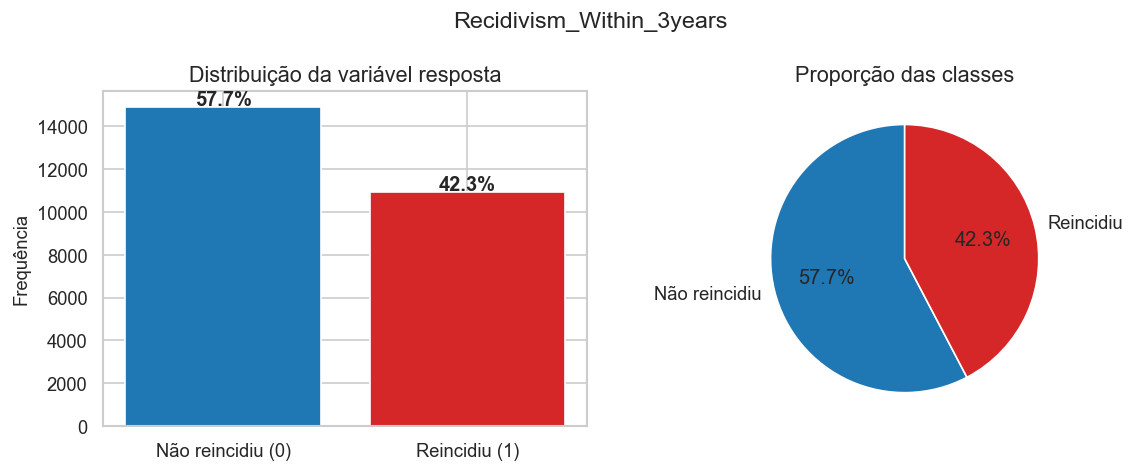

In [10]:
print("=== VARIÁVEL RESPOSTA ===")
vc = df[LABEL].value_counts()
pct = df[LABEL].value_counts(normalize=True) * 100
print(pd.DataFrame({'N': vc, '%': pct.round(1)}))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Gráfico de barras
axes[0].bar(['Não reincidiu (0)', 'Reincidiu (1)'],
            vc.values, color=['#1f77b4', '#d62728'], edgecolor='white')
for i, (n, p) in enumerate(zip(vc.values, pct.values)):
    axes[0].text(i, n + 100, f'{p:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('Distribuição da variável resposta')
axes[0].set_ylabel('Frequência')

# Pizza
axes[1].pie(vc.values, labels=['Não reincidiu', 'Reincidiu'],
            autopct='%1.1f%%', colors=['#1f77b4', '#d62728'],
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Proporção das classes')

plt.suptitle('Recidivism_Within_3years', fontsize=14)
plt.tight_layout()
plt.show()

=== ESTATÍSTICAS DESCRITIVAS — VARIÁVEIS CONTÍNUAS ===
       Supervision_Risk_Score_First  Avg_Days_per_DrugTest  DrugTests_THC_Positive  DrugTests_Cocaine_Positive  DrugTests_Meth_Positive  DrugTests_Other_Positive  Percent_Days_Employed  Jobs_Per_Year
count                     25835.000              25835.000               25835.000                   25835.000                25835.000                 25835.000              25835.000      25835.000
mean                          6.081                 84.803                   0.051                       0.011                    0.010                     0.006                  0.482          0.765
std                           2.359                103.694                   0.126                       0.055                    0.054                     0.037                  0.421          0.801
min                           1.000                  0.500                   0.000                       0.000                    0.000          

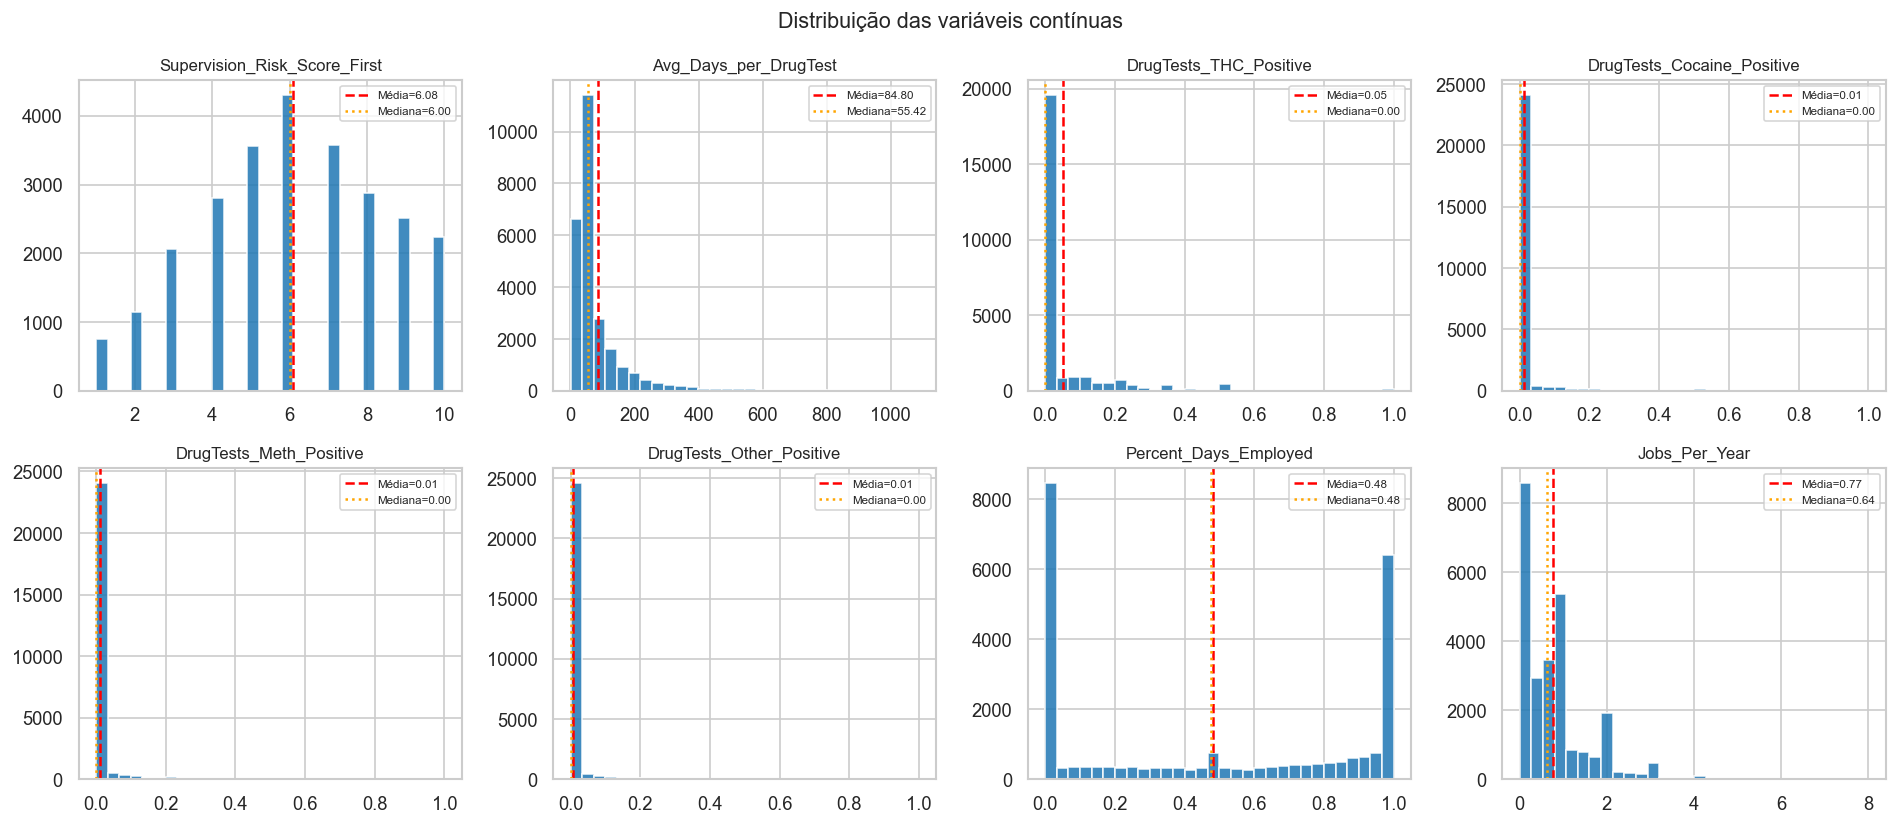

In [11]:

CONTINUAS = ['Supervision_Risk_Score_First', 'Avg_Days_per_DrugTest',
             'DrugTests_THC_Positive', 'DrugTests_Cocaine_Positive',
             'DrugTests_Meth_Positive', 'DrugTests_Other_Positive',
             'Percent_Days_Employed', 'Jobs_Per_Year']

print("=== ESTATÍSTICAS DESCRITIVAS — VARIÁVEIS CONTÍNUAS ===")
print(df[CONTINUAS].describe().round(3).to_string())

n_cols = 4
n_rows = int(np.ceil(len(CONTINUAS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flat

for ax, col in zip(axes, CONTINUAS):
    ax.hist(df[col], bins=30, color='#1f77b4', edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(),   color='red',    linestyle='--', linewidth=1.5,
               label=f'Média={df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='orange', linestyle=':',  linewidth=1.5,
               label=f'Mediana={df[col].median():.2f}')
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=7)

for ax in list(axes)[len(CONTINUAS):]:
    ax.set_visible(False)

plt.suptitle('Distribuição das variáveis contínuas', fontsize=13)
plt.tight_layout()
plt.show()

In [12]:
# Taxa de reincidência por variável categórica
cat_cols = df.select_dtypes(include=['object', 'string']).columns.difference(
    ['Recidivism_Within_3years', 'Recidivism_Arrest_Year1', 'Recidivism_Arrest_Year2', 'Recidivism_Arrest_Year3']
)

# Separar variáveis binárias das não-binárias
binary_cols = [col for col in cat_cols if df[col].nunique() == 2]
non_binary_cols = [col for col in cat_cols if df[col].nunique() > 2]

# --- Gráfico único para variáveis binárias: barra dividida (stacked) ---
if binary_cols:
    # Para cada variável binária, calcular percentual de No e Yes
    no_pcts = []
    yes_pcts = []
    for col in binary_cols:
        counts = df[col].value_counts(normalize=True) * 100
        no_pcts.append(counts.get('No', counts.get(0, 0)))
        yes_pcts.append(counts.get('Yes', counts.get(1, 0)))

    y_pos = np.arange(len(binary_cols))
    bar_height = 0.6

    plt.figure(figsize=(12, max(4, len(binary_cols) * 0.8)))

    # Barra azul (No) como base
    bars_no = plt.barh(y_pos, no_pcts, height=bar_height, color='#4C72B0', label='No')
    # Barra vermelha (Yes) empilhada à direita
    bars_yes = plt.barh(y_pos, yes_pcts, height=bar_height, left=no_pcts, color='#C44E52', label='Yes')

    # Anotar percentuais dentro das barras
    for i, (no, yes) in enumerate(zip(no_pcts, yes_pcts)):
        if no > 8:
            plt.text(no / 2, y_pos[i], f'{no:.1f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
        if yes > 8:
            plt.text(no + yes / 2, y_pos[i], f'{yes:.1f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')

    plt.yticks(y_pos, binary_cols)
    plt.xlabel('Percentual (%)')
    plt.title('Distribuição das Variáveis Binárias')
    plt.legend(title='Classe', loc='lower right')
    plt.xlim(0, 100)
    plt.tight_layout()
    plt.show()

# --- Gráficos individuais para variáveis não-binárias ---
if non_binary_cols:
    n_plots = len(non_binary_cols)
    n_cols_grid = 3
    n_rows = (n_plots + n_cols_grid - 1) // n_cols_grid
    fig, axes = plt.subplots(n_rows, n_cols_grid, figsize=(18, 5 * n_rows))
    axes = axes.flatten() if n_plots > 1 else [axes]

    for i, col in enumerate(non_binary_cols):
        rate = df.groupby(col)['Target'].mean().sort_values(ascending=False)
        rate.plot(kind='bar', ax=axes[i], color='steelblue')
        axes[i].set_title(f'Taxa de Reincidência por {col}', fontsize=10)
        axes[i].set_ylabel('Taxa')
        axes[i].set_ylim(0, 1)
        axes[i].tick_params(axis='x', rotation=45, labelsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

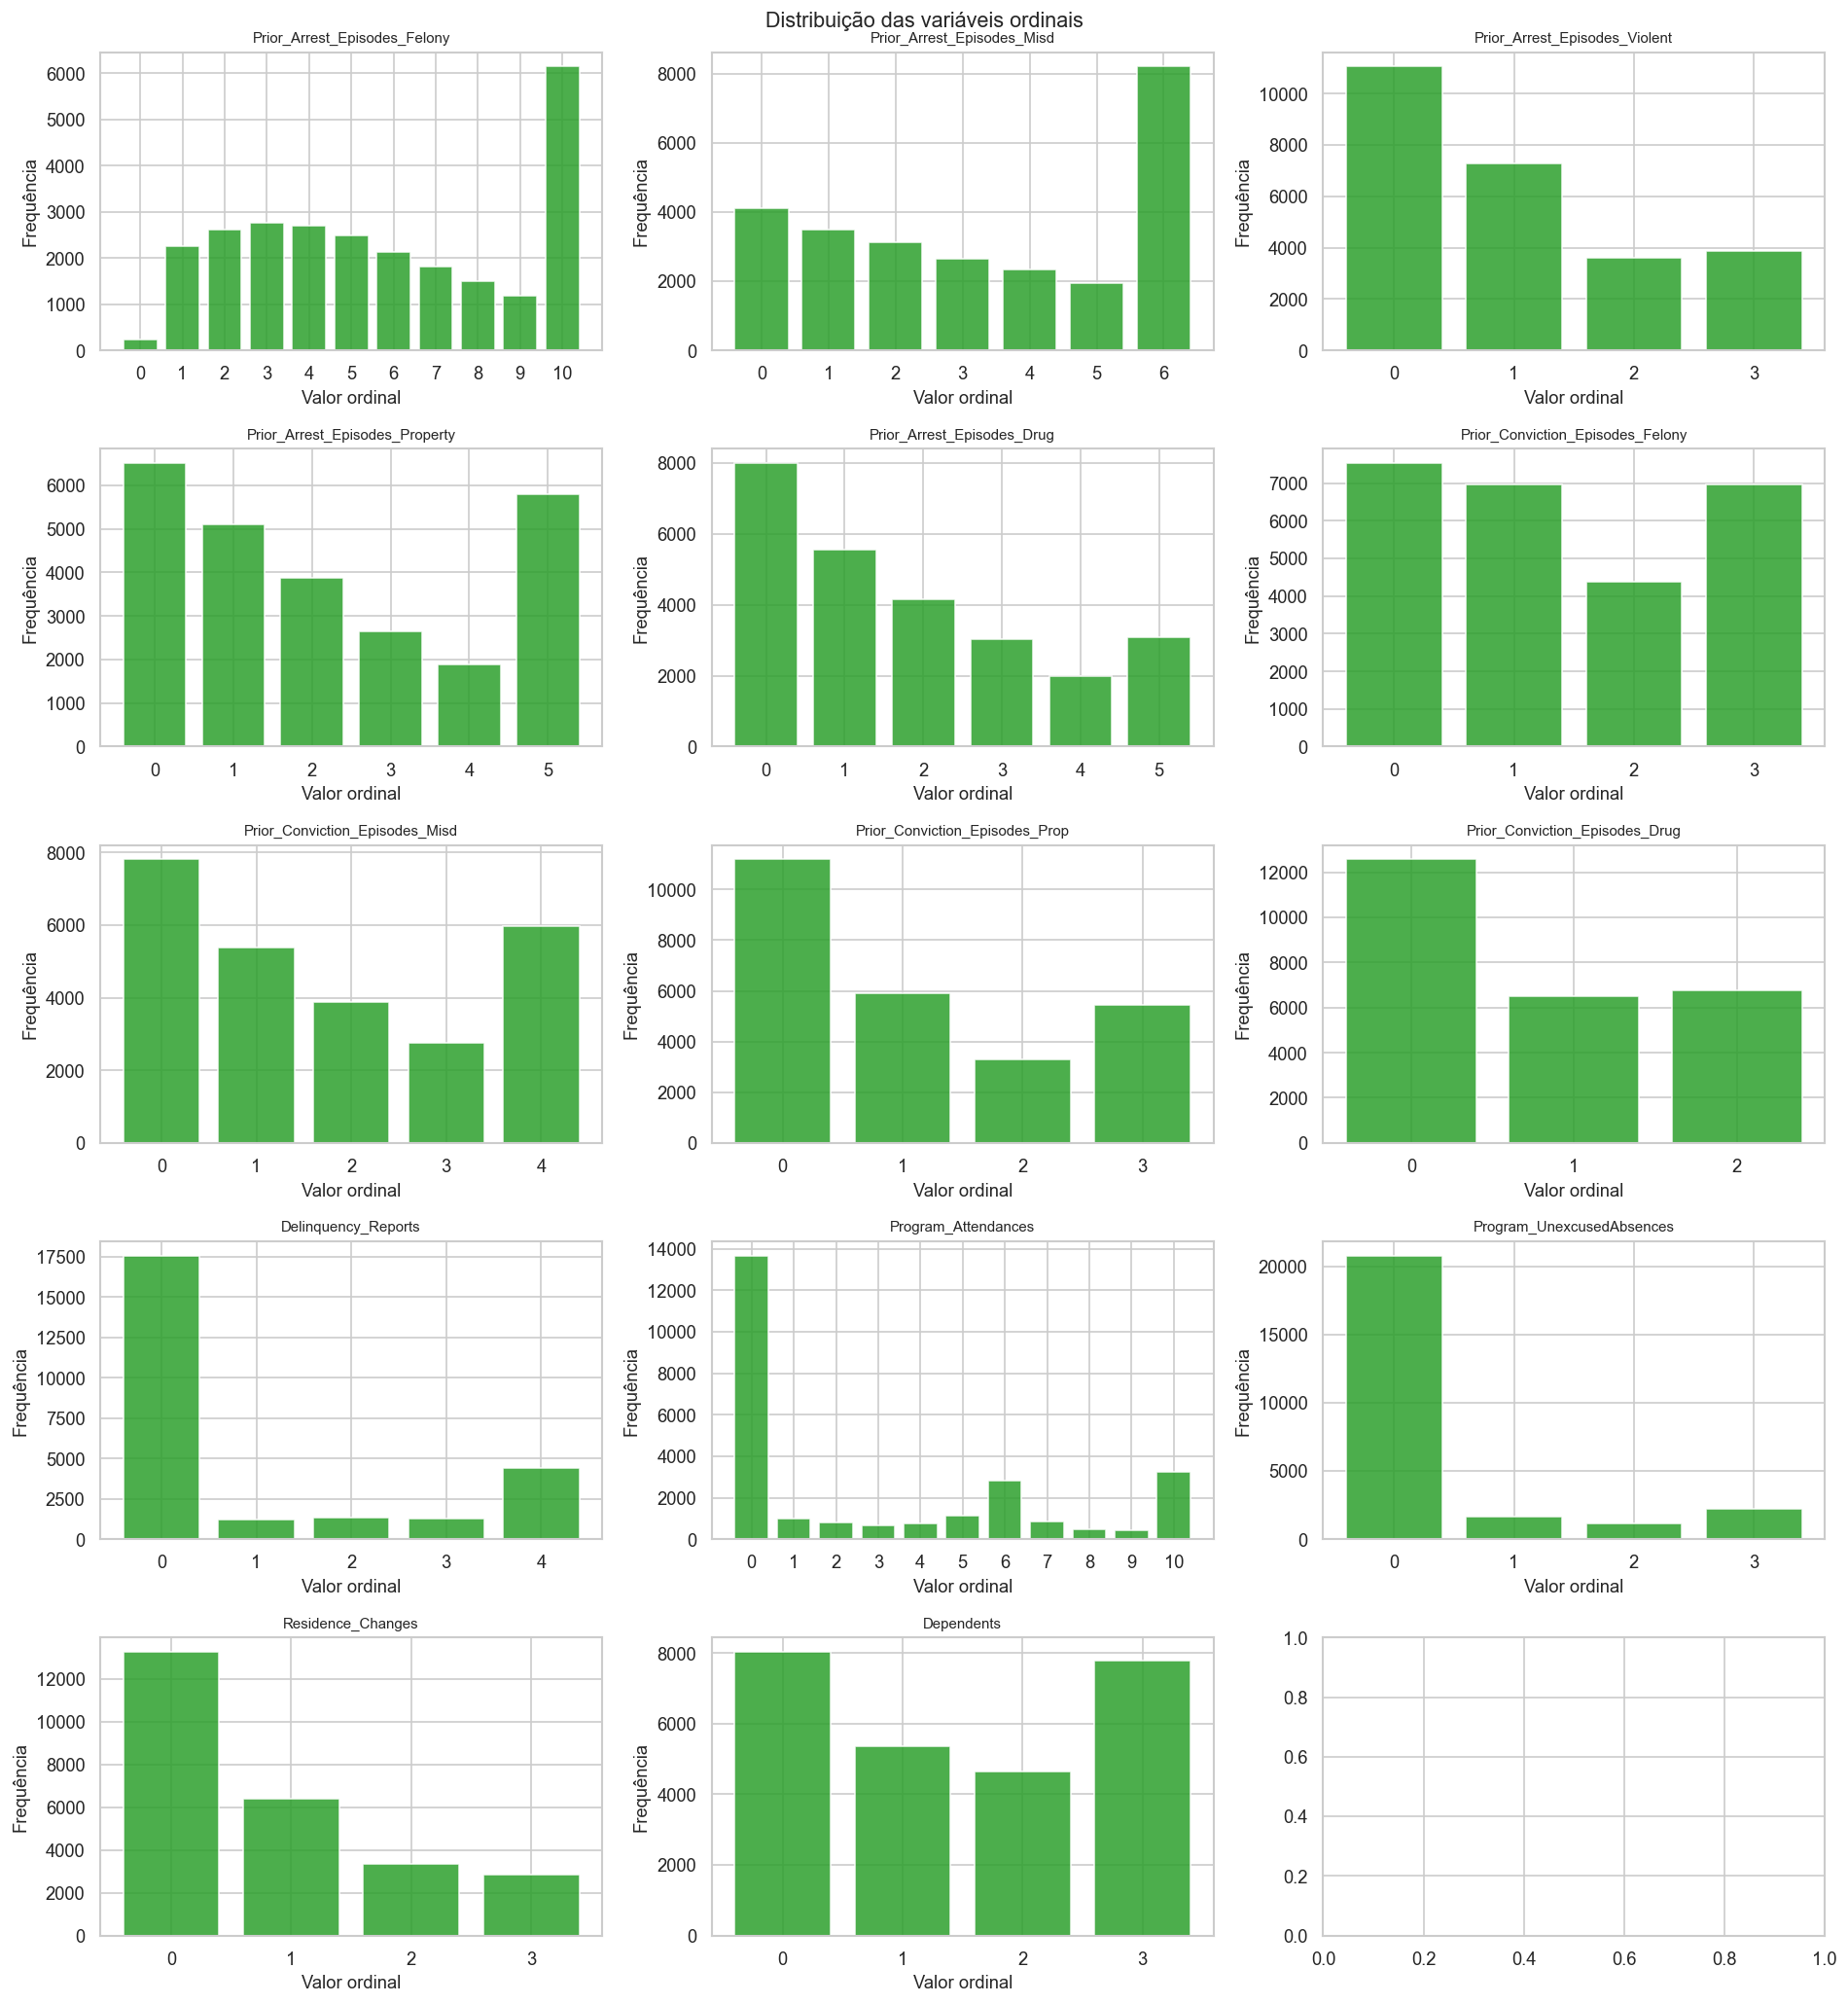

In [11]:
ORDINAIS = list(MAPA_ORDINAIS.keys())

n_cols = 3
n_rows = int(np.ceil(len(ORDINAIS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flat

for ax, col in zip(axes, ORDINAIS):
    vc_col = df[col].value_counts().sort_index()
    ax.bar(vc_col.index.astype(str), vc_col.values,
           color='#2ca02c', edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('Valor ordinal')
    ax.set_ylabel('Frequência')

for ax in list(axes)[len(ORDINAIS):]:
    ax.set_visible(False)

plt.suptitle('Distribuição das variáveis ordinais', fontsize=13)
plt.tight_layout()
plt.show()


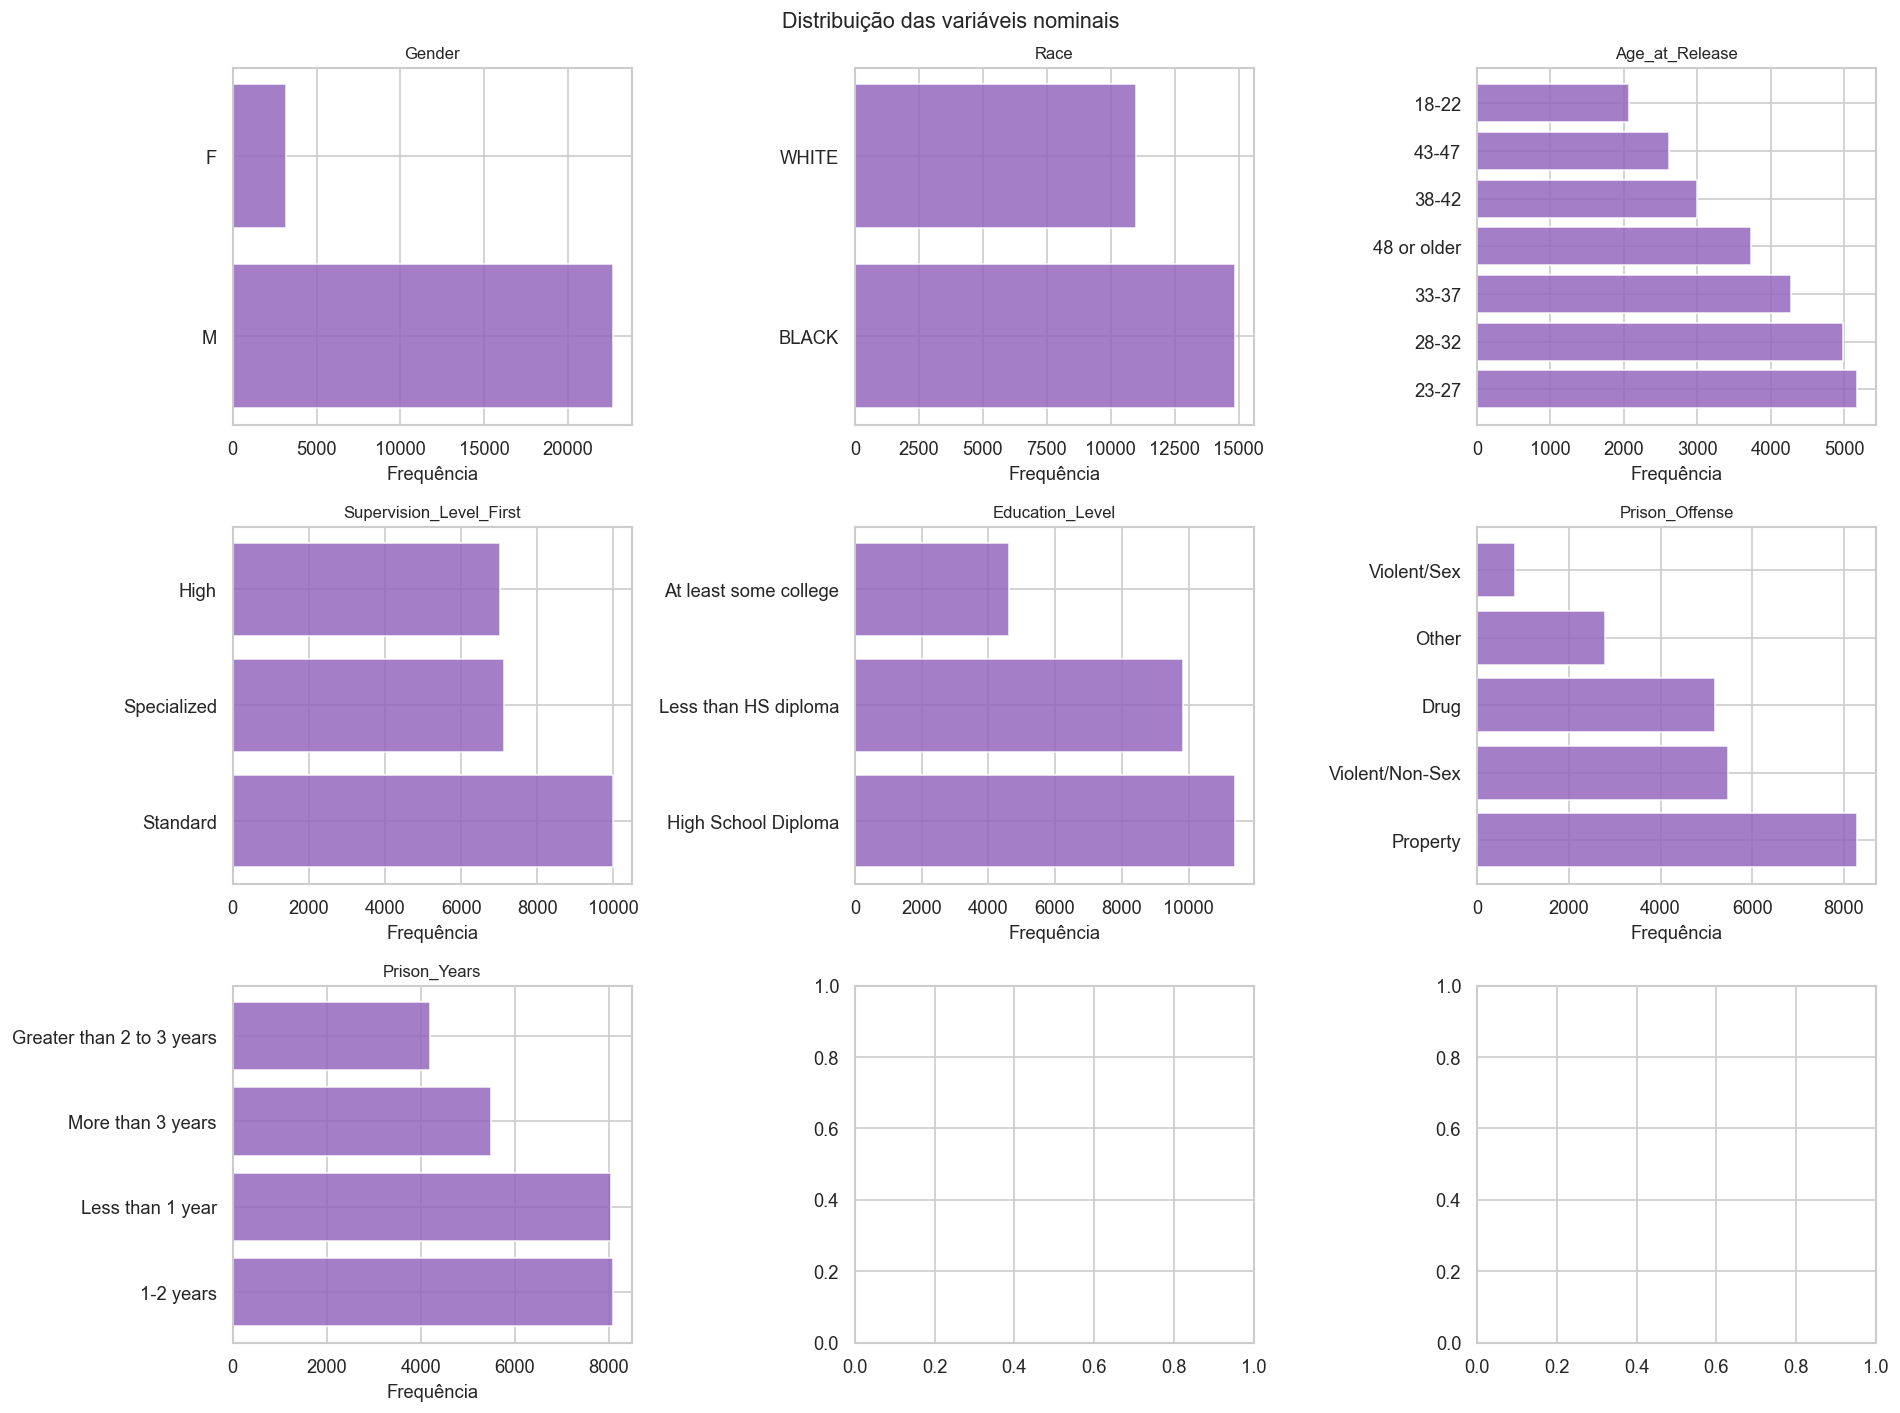

In [12]:

# Reconstruir categorias originais para melhor visualização
df_viz = df_raw.drop(columns=REMOVER).copy()
df_viz[LABEL] = df_viz[LABEL].map({'Yes': 'Reincidiu', 'No': 'Não reincidiu'})

NOMINAIS_ORIG = ['Gender', 'Race', 'Age_at_Release', 'Supervision_Level_First',
                 'Education_Level', 'Prison_Offense', 'Prison_Years']

n_cols = 3
n_rows = int(np.ceil(len(NOMINAIS_ORIG) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flat

for ax, col in zip(axes, NOMINAIS_ORIG):
    vc_col = df_viz[col].value_counts()
    ax.barh(vc_col.index.astype(str), vc_col.values,
            color='#9467bd', edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('Frequência')

for ax in list(axes)[len(NOMINAIS_ORIG):]:
    ax.set_visible(False)

plt.suptitle('Distribuição das variáveis nominais', fontsize=13)
plt.tight_layout()
plt.show()

# Análise bivariada

=== ANÁLISE BIVARIADA: CONTÍNUAS vs. LABEL ===
Recidivism_Within_3years      Mediana — Não reincidiu  Mediana — Reincidiu
Supervision_Risk_Score_First                    6.000                6.000
Avg_Days_per_DrugTest                          55.425               55.425
DrugTests_THC_Positive                          0.000                0.000
DrugTests_Cocaine_Positive                      0.000                0.000
DrugTests_Meth_Positive                         0.000                0.000
DrugTests_Other_Positive                        0.000                0.000
Percent_Days_Employed                           0.772                0.250
Jobs_Per_Year                                   0.635                0.607


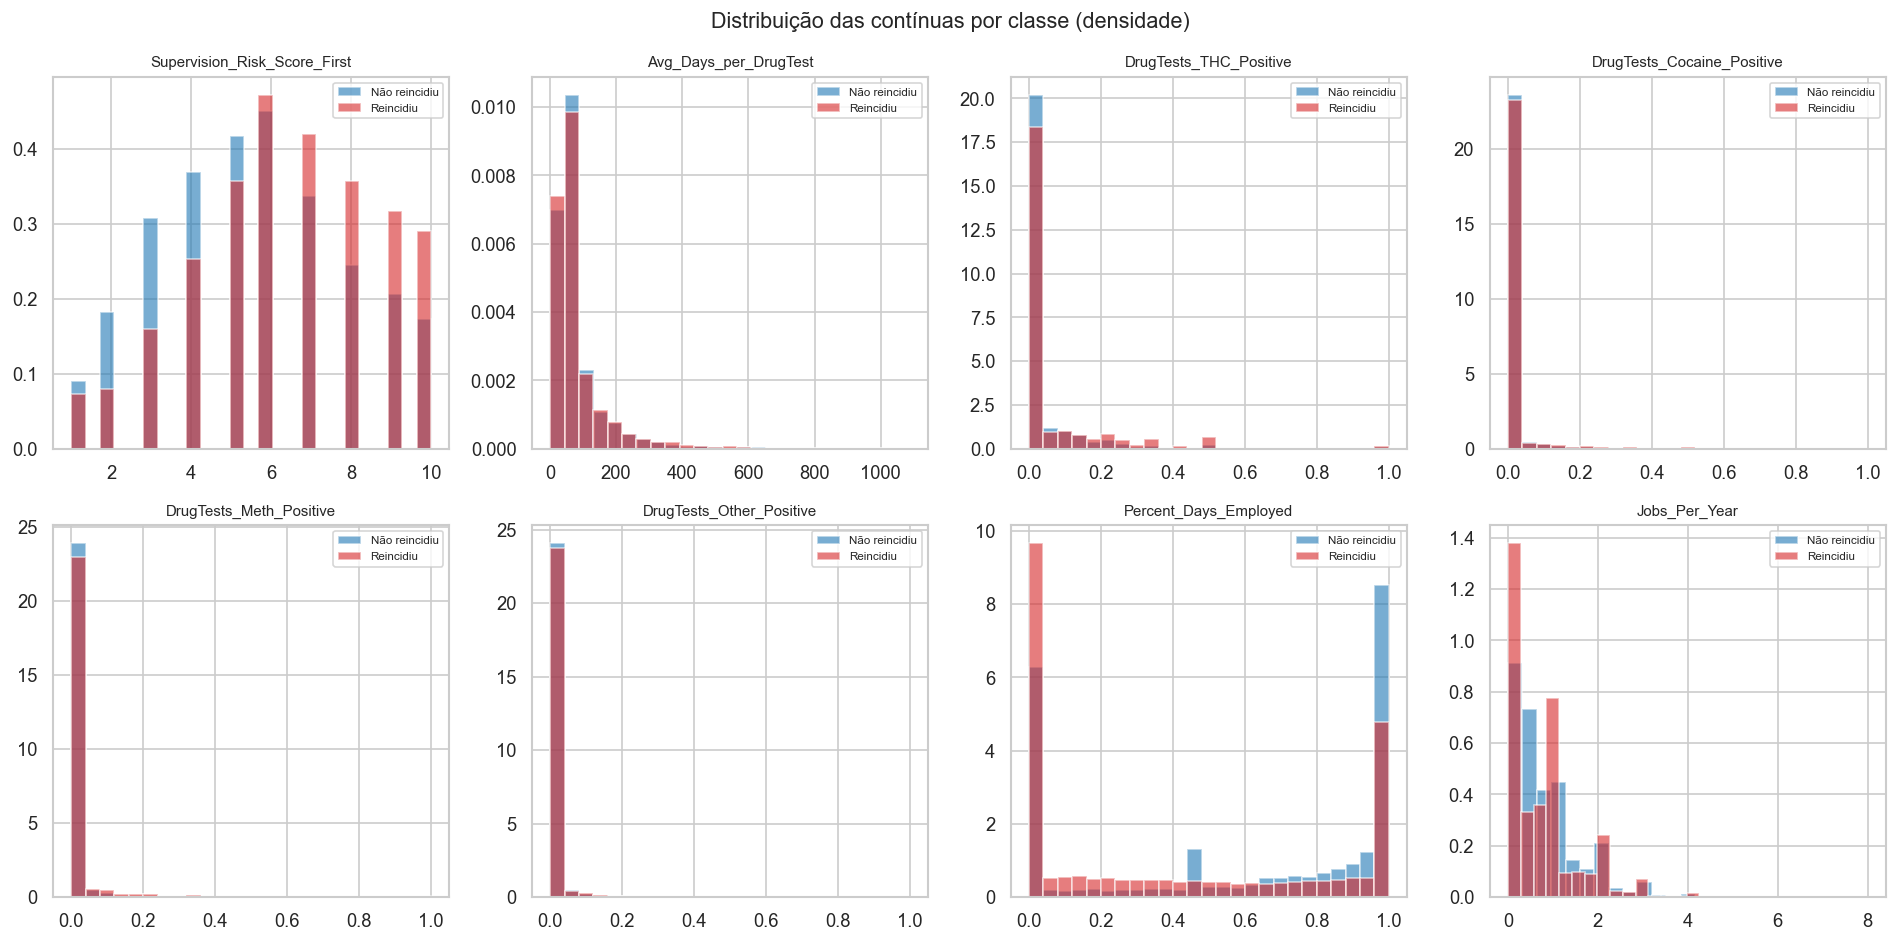

In [13]:

print("=== ANÁLISE BIVARIADA: CONTÍNUAS vs. LABEL ===")
print(df.groupby(LABEL)[CONTINUAS].median().T.rename(
    columns={0: 'Mediana — Não reincidiu', 1: 'Mediana — Reincidiu'}).round(3))

n_cols = 4
n_rows = int(np.ceil(len(CONTINUAS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flat

for ax, col in zip(axes, CONTINUAS):
    data0 = df[df[LABEL] == 0][col].dropna()
    data1 = df[df[LABEL] == 1][col].dropna()
    ax.hist(data0, bins=25, alpha=0.6, color='#1f77b4',
            density=True, label='Não reincidiu')
    ax.hist(data1, bins=25, alpha=0.6, color='#d62728',
            density=True, label='Reincidiu')
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)

for ax in list(axes)[len(CONTINUAS):]:
    ax.set_visible(False)

plt.suptitle('Distribuição das contínuas por classe (densidade)',
             fontsize=13)
plt.tight_layout()
plt.show()



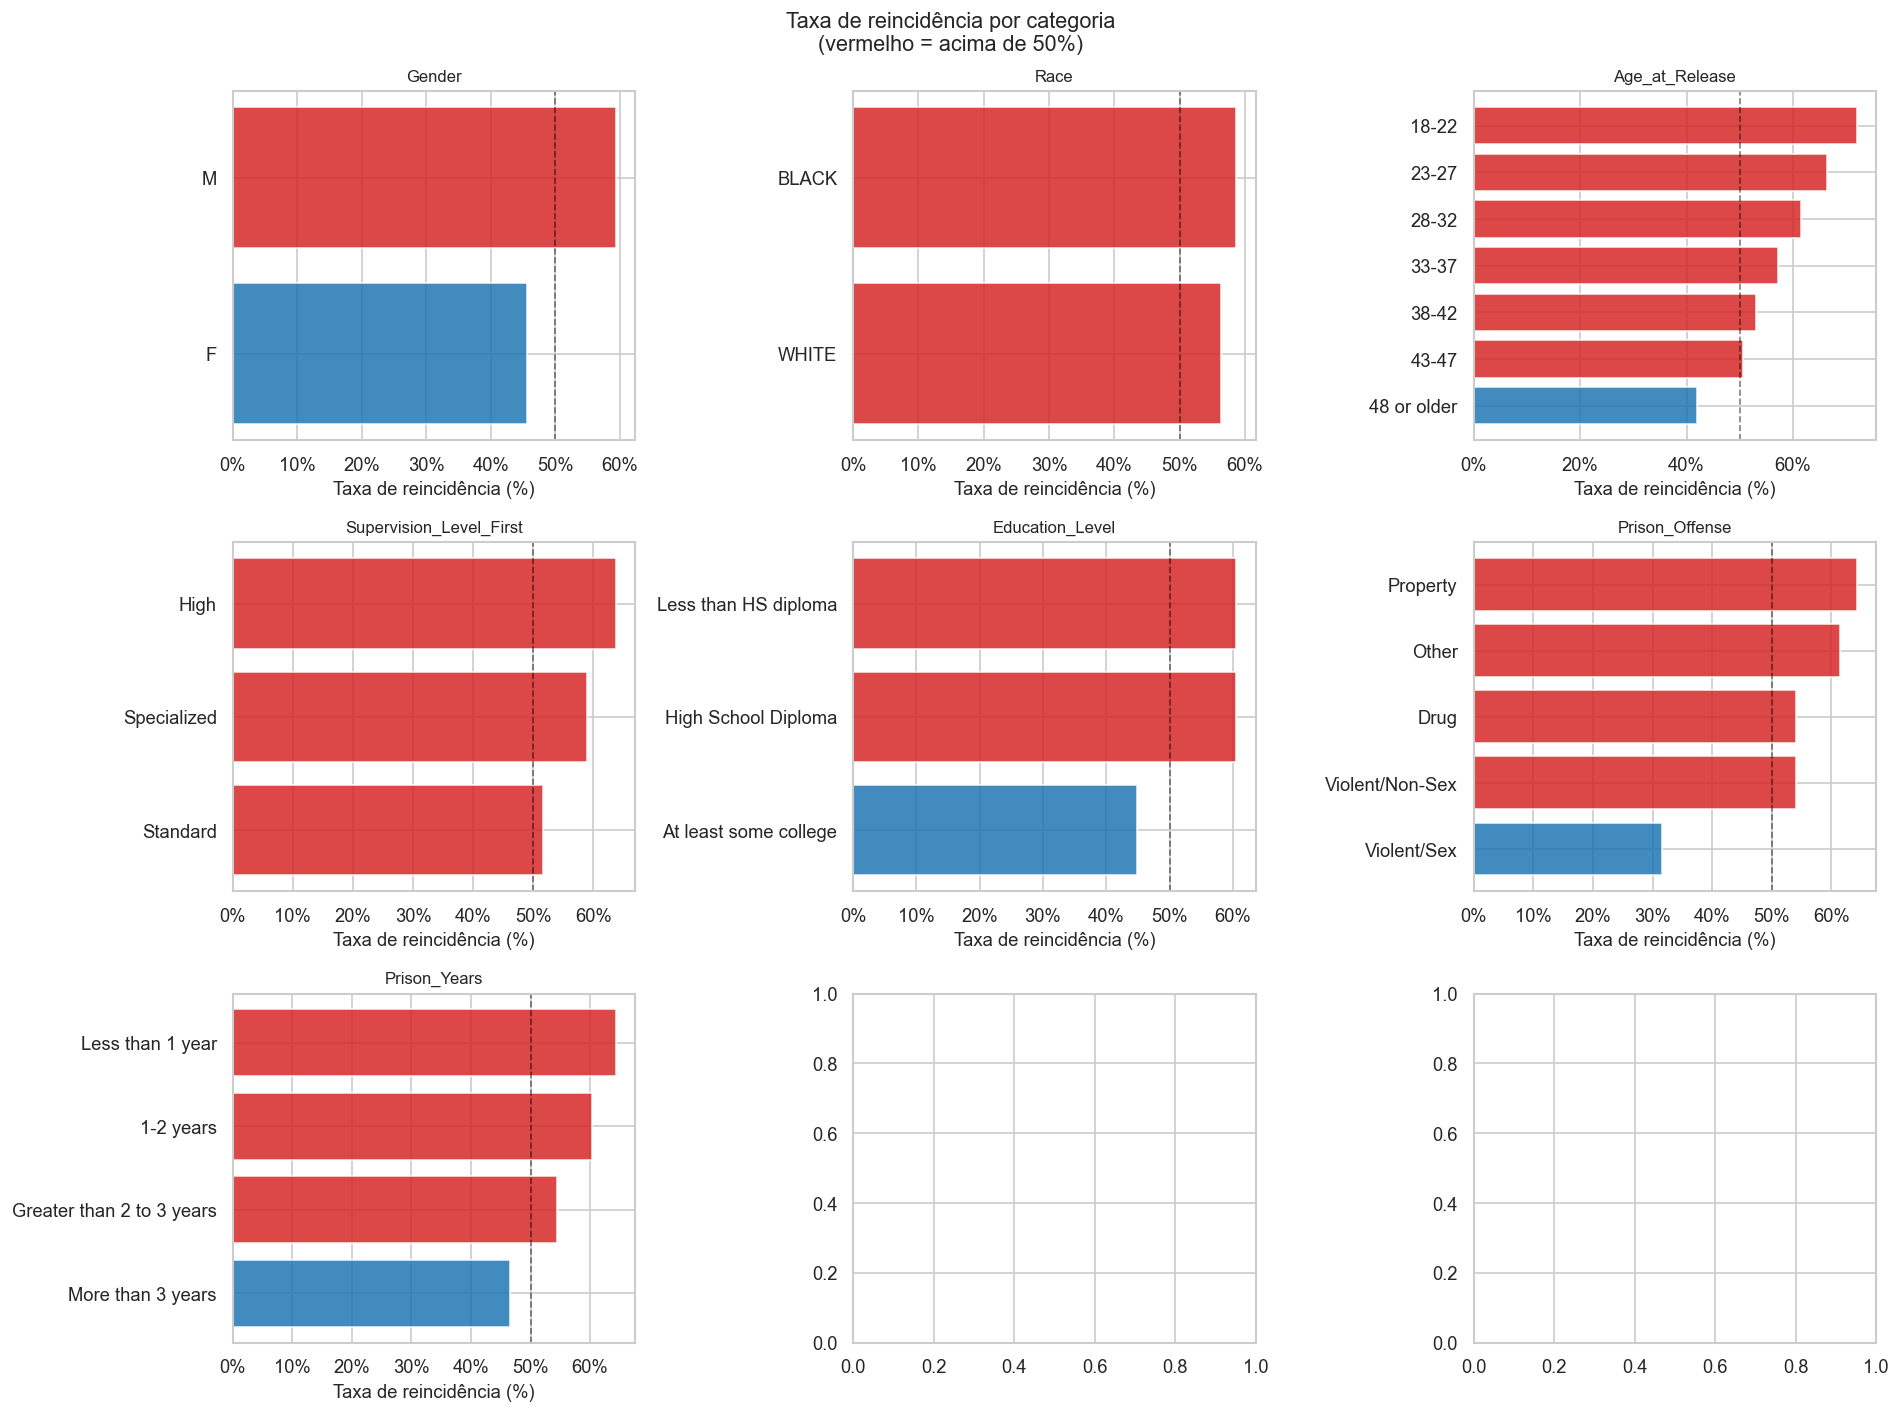

In [14]:
# Análise bivariada: nominais e binárias vs. label
# Taxa de reincidência por categoria — variáveis nominais originais
n_cols = 3
n_rows = int(np.ceil(len(NOMINAIS_ORIG) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flat

for ax, col in zip(axes, NOMINAIS_ORIG):
    taxa = (df_viz.groupby(col)[LABEL]
            .apply(lambda s: (s == 'Reincidiu').mean() * 100)
            .sort_values(ascending=True))
    cores = ['#d62728' if v >= 50 else '#1f77b4' for v in taxa.values]
    ax.barh(taxa.index.astype(str), taxa.values, color=cores,
            edgecolor='white', alpha=0.85)
    ax.axvline(50, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xlabel('Taxa de reincidência (%)')
    ax.set_title(col, fontsize=10)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())

for ax in list(axes)[len(NOMINAIS_ORIG):]:
    ax.set_visible(False)

plt.suptitle('Taxa de reincidência por categoria\n(vermelho = acima de 50%)',
             fontsize=13)
plt.tight_layout()
plt.show()



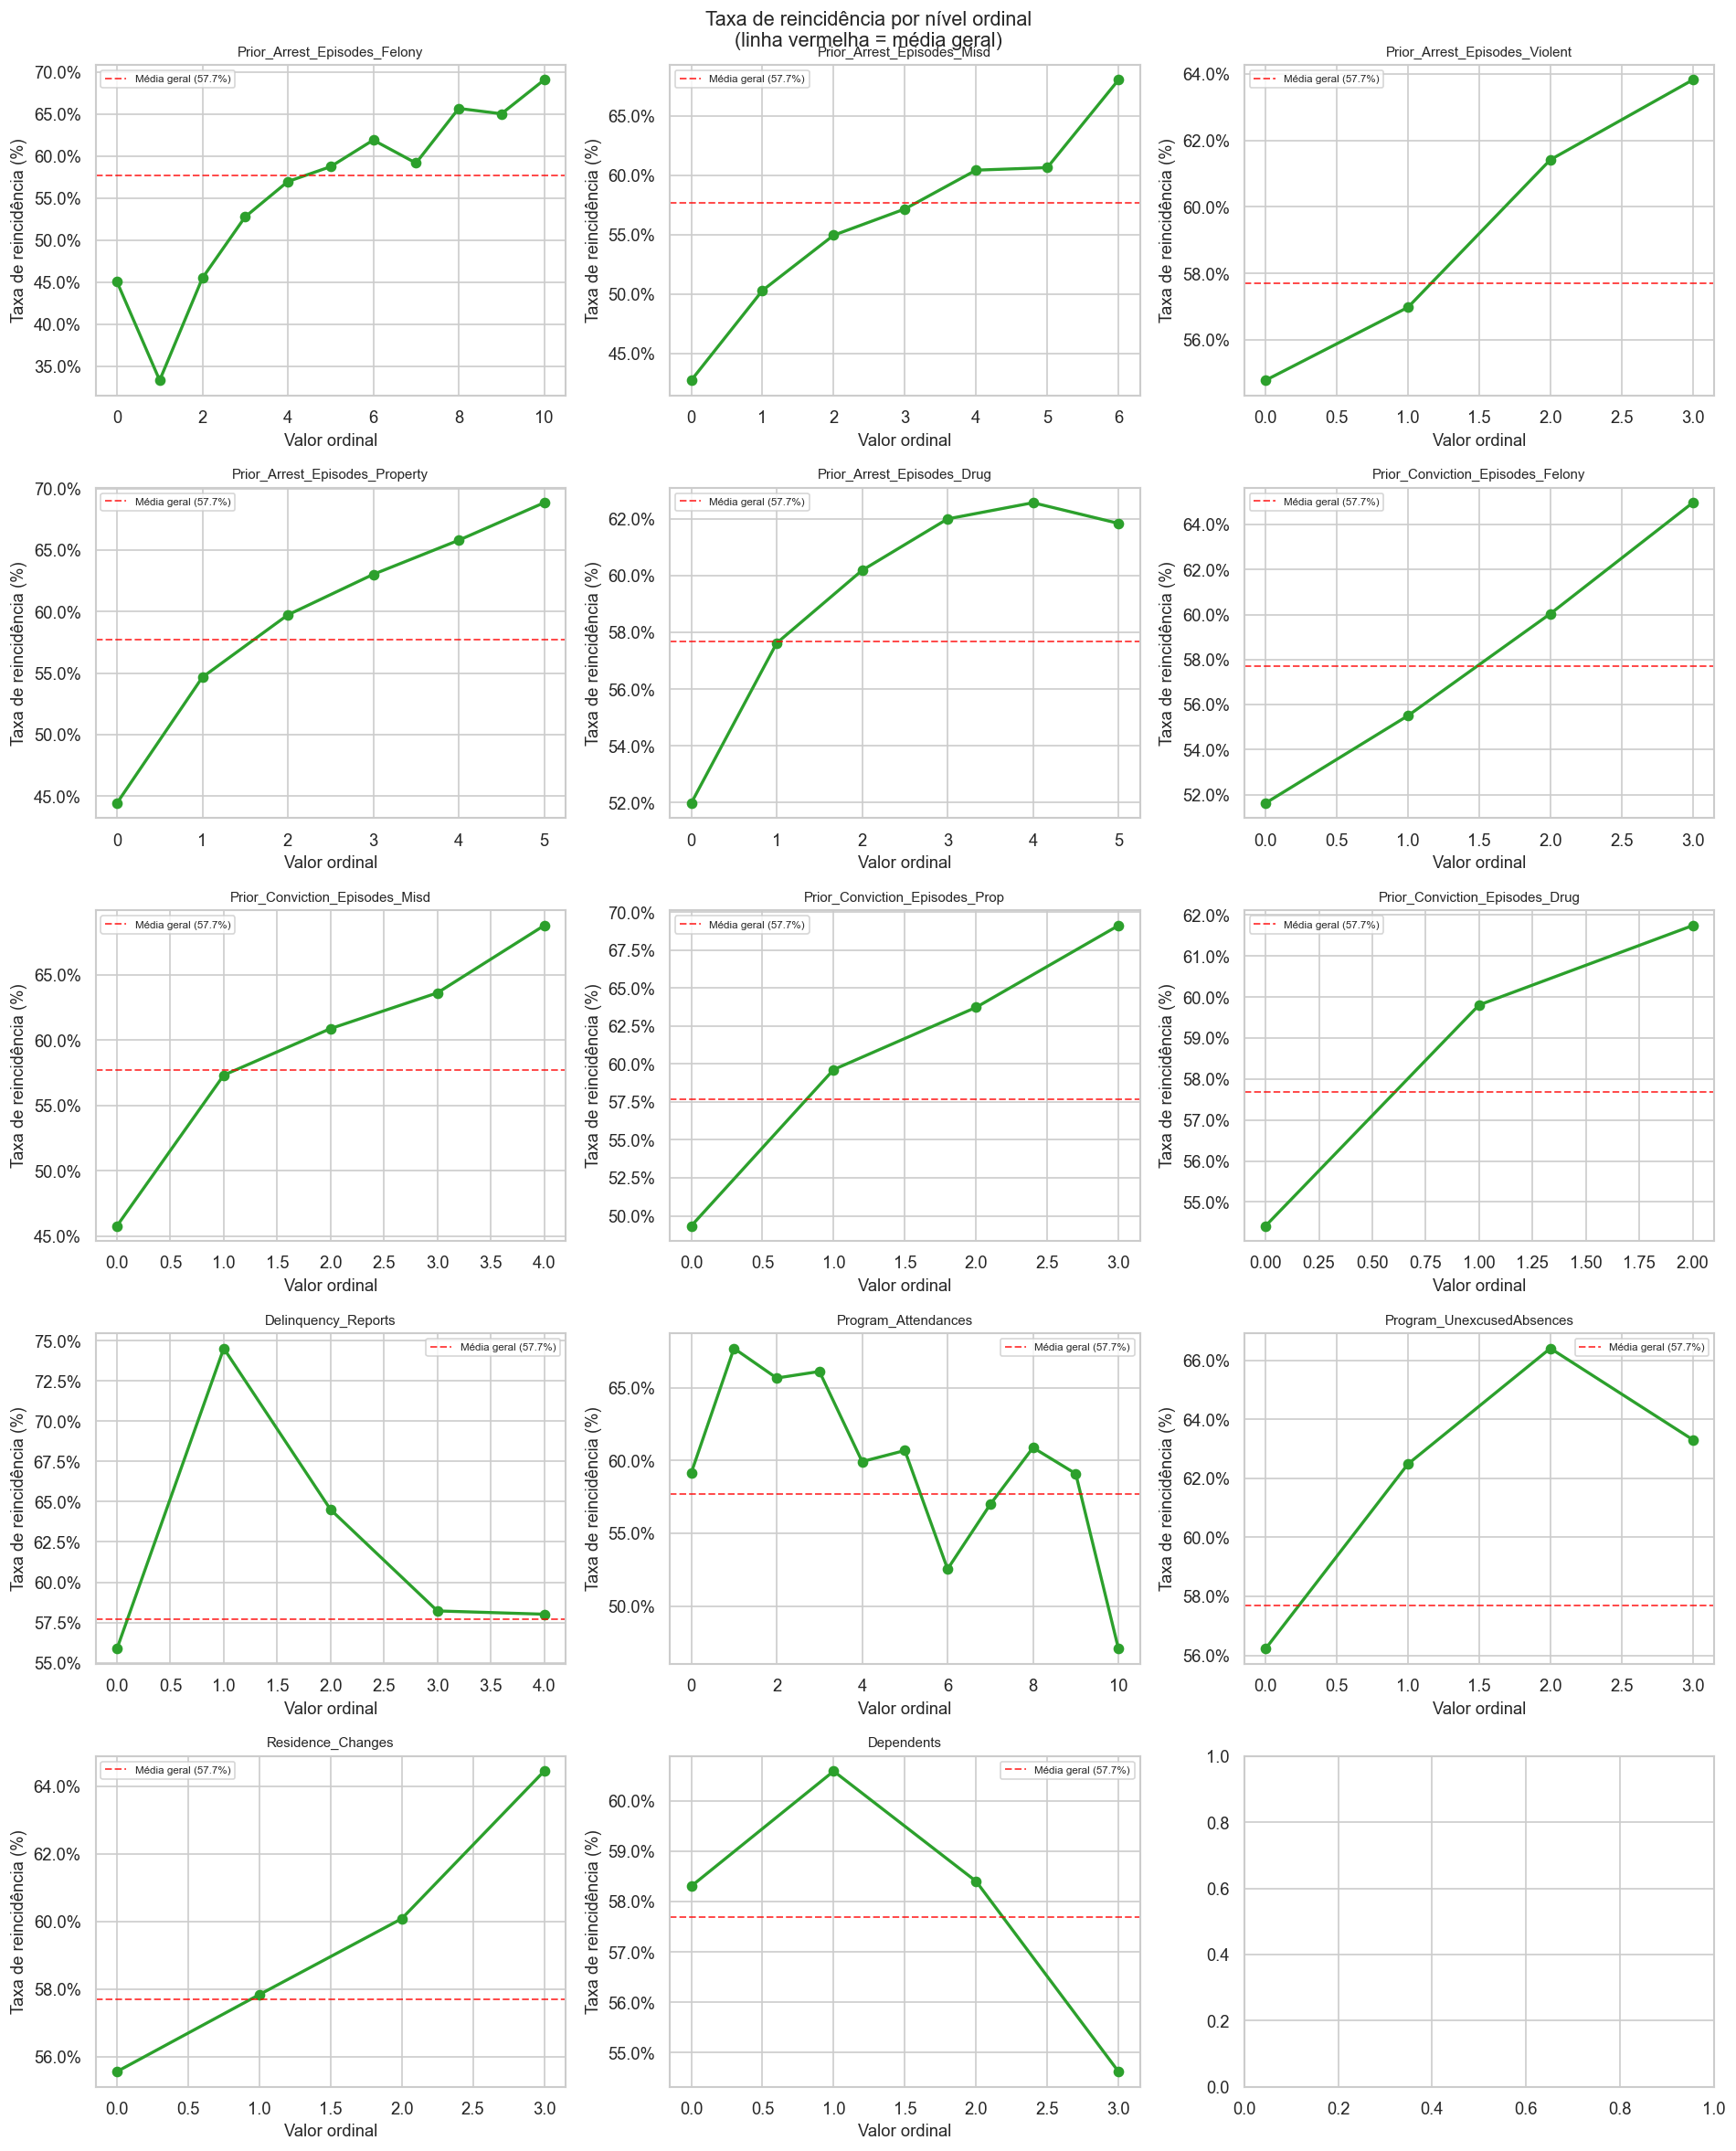

In [15]:
# Análise bivariada: ordinais vs. label (taxa de reincidência)

n_cols = 3
n_rows = int(np.ceil(len(ORDINAIS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flat

for ax, col in zip(axes, ORDINAIS):
    taxa = (df.groupby(col)[LABEL].mean() * 100).sort_index()
    ax.plot(taxa.index, taxa.values, marker='o',
            color='#2ca02c', linewidth=2, markersize=6)
    ax.axhline(df[LABEL].mean() * 100, color='red',
               linestyle='--', linewidth=1.2, alpha=0.7,
               label=f'Média geral ({df[LABEL].mean()*100:.1f}%)')
    ax.set_xlabel('Valor ordinal')
    ax.set_ylabel('Taxa de reincidência (%)')
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())

for ax in list(axes)[len(ORDINAIS):]:
    ax.set_visible(False)

plt.suptitle('Taxa de reincidência por nível ordinal\n(linha vermelha = média geral)',
             fontsize=13)
plt.tight_layout()
plt.show()


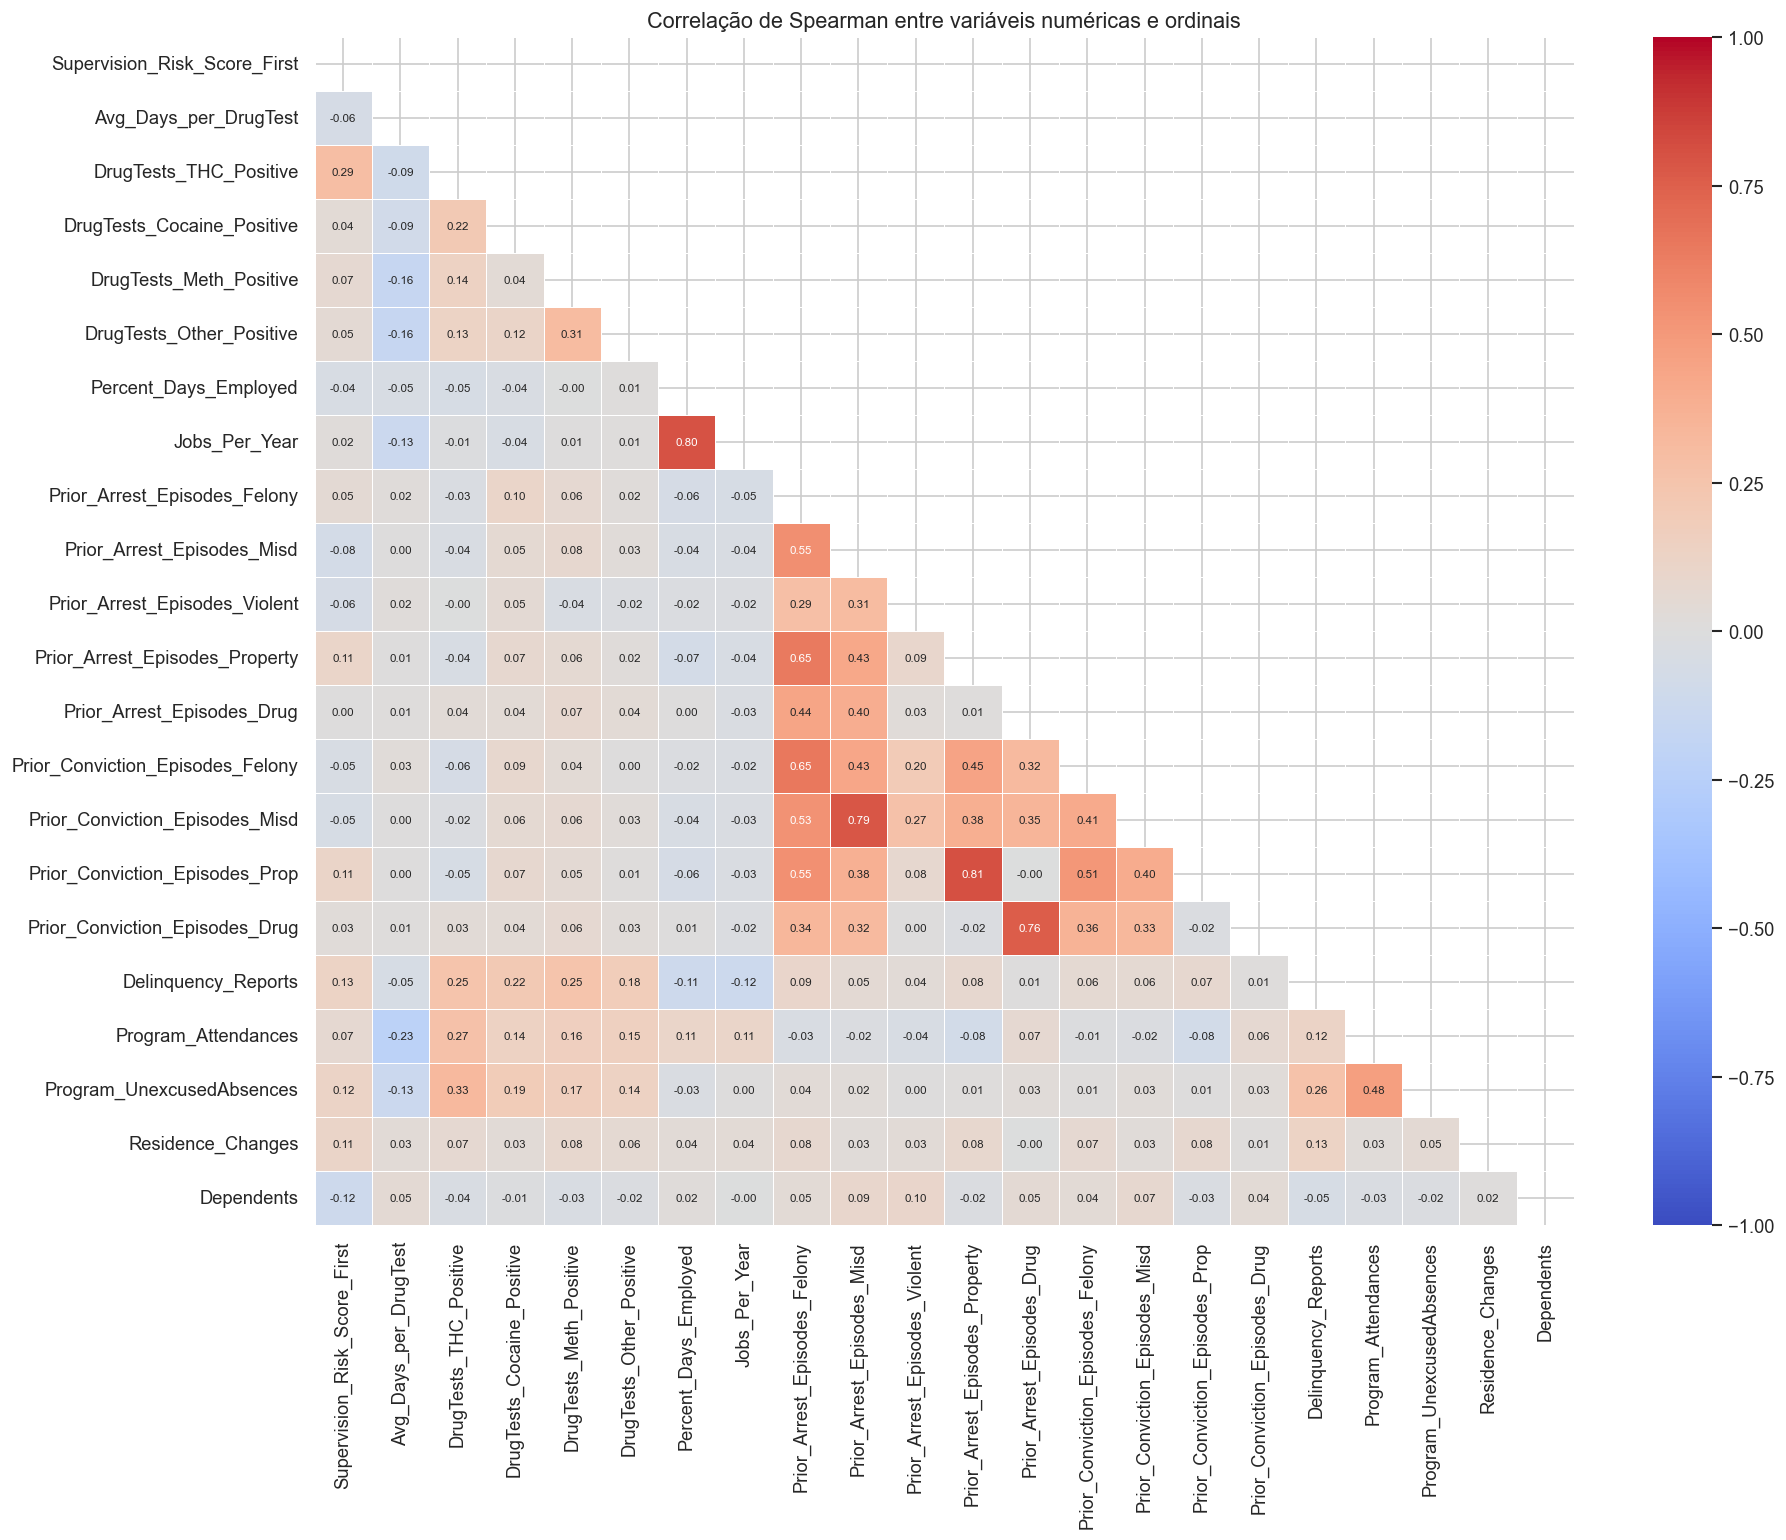

In [16]:
# Correlação entre variáveis numéricas (heatmap)

TODAS_NUMERICAS = CONTINUAS + ORDINAIS
corr = df[TODAS_NUMERICAS].corr(method='spearman')

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))  # mostrar só triângulo inferior
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, annot_kws={'size': 7},
            linewidths=0.5)
ax.set_title('Correlação de Spearman entre variáveis numéricas e ordinais',
             fontsize=13)
plt.tight_layout()
plt.show()


# 3. Preparação dos Dados (Data Preparation)

Seleciona, limpa, transforma e formata os dados para modelagem. Esta etapa costuma consumir a maior parte do tempo do projeto (60-70%).

# Modelagem

In [17]:
FEATURES = [c for c in df.columns if c != LABEL]

X = df[FEATURES]
y = df[LABEL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y)

print(f"Treino : {X_train.shape[0]:,} registros")
print(f"Teste  : {X_test.shape[0]:,} registros")
print(f"\nProporção da label no treino :")
print((y_train.value_counts(normalize=True) * 100).round(1))
print(f"\nProporção da label no teste  :")
print((y_test.value_counts(normalize=True) * 100).round(1))

Treino : 18,084 registros
Teste  : 7,751 registros

Proporção da label no treino :
Recidivism_Within_3years
1    57.7
0    42.3
Name: proportion, dtype: float64

Proporção da label no teste  :
Recidivism_Within_3years
1    57.7
0    42.3
Name: proportion, dtype: float64


In [18]:
def _extrair_folhas_roc(modelo, feature_names, X_te, y_te):
    """Extrai pontos operacionais (FPR, TPR) de cada folha da árvore para o ROC."""
    tree = modelo.tree_
    feature_names = list(feature_names)

    # Obter o índice da folha para cada amostra de teste
    folha_ids = modelo.apply(X_te)
    y_arr = np.array(y_te)

    total_pos = (y_arr == 1).sum()
    total_neg = (y_arr == 0).sum()

    # Para cada folha, calcular proporção de positivos (pureza)
    folhas_unicas = np.unique(folha_ids)
    folhas_info = []

    for fid in folhas_unicas:
        mask = folha_ids == fid
        n = mask.sum()
        n_pos = (y_arr[mask] == 1).sum()
        n_neg = (y_arr[mask] == 0).sum()
        pureza = n_pos / n if n > 0 else 0
        gini = round(float(tree.impurity[fid]), 4)

        # Reconstruir o caminho (regras) até esta folha
        caminho = _caminho_folha(tree, fid, feature_names)

        folhas_info.append({
            'id': int(fid),
            'n': n, 'n_pos': n_pos, 'n_neg': n_neg,
            'pureza': pureza,
            'pct_reincid': round(pureza * 100, 1),
            'gini': gini,
            'caminho': caminho,
            'fpr_contrib': n_neg / total_neg if total_neg > 0 else 0,
            'tpr_contrib': n_pos / total_pos if total_pos > 0 else 0,
        })

    # Ordenar por pureza decrescente (folhas mais "positivas" primeiro)
    folhas_info.sort(key=lambda x: x['pureza'], reverse=True)

    # Acumular FPR e TPR para traçar o polígono ROC
    fpr_acum = [0.0]
    tpr_acum = [0.0]
    labels = ['Origem (0,0)']

    for f in folhas_info:
        fpr_acum.append(fpr_acum[-1] + f['fpr_contrib'])
        tpr_acum.append(tpr_acum[-1] + f['tpr_contrib'])
        labels.append(
            f"Folha #{f['id']}<br>"
            f"Regras: {f['caminho']}<br>"
            f"n={f['n']} | Reincidência={f['pct_reincid']}%<br>"
            f"Gini={f['gini']}"
        )

    return fpr_acum, tpr_acum, labels


def _caminho_folha(tree, folha_id, feature_names):
    """Reconstrói o caminho de regras da raiz até a folha."""
    node_id = 0
    target = int(folha_id)
    caminho = []

    def buscar(nid, regras):
        if nid == target:
            return regras[:]
        left = int(tree.children_left[nid])
        right = int(tree.children_right[nid])
        if left == _tree.TREE_LEAF:
            return None
        feat = feature_names[int(tree.feature[nid])]
        thres = round(float(tree.threshold[nid]), 2)

        # Tentar esquerda
        res = buscar(left, regras + [f'{feat} ≤ {thres}'])
        if res is not None:
            return res
        # Tentar direita
        res = buscar(right, regras + [f'{feat} > {thres}'])
        if res is not None:
            return res
        return None

    regras = buscar(0, [])
    if regras:
        return '<br>'.join(regras[-3:])  # últimas 3 regras para não ficar enorme
    return 'Raiz'


def avaliar_modelo(nome, modelo, X_tr, y_tr, X_te, y_te):
    """Imprime métricas e plota matriz de confusão + curva ROC (polígono das folhas)."""

    y_pred  = modelo.predict(X_te)
    y_proba = modelo.predict_proba(X_te)[:, 1]

    print(f"\n{'='*60}")
    print(f"  {nome}")
    print(f"{'='*60}")
    print(f"  Acurácia (treino) : {accuracy_score(y_tr, modelo.predict(X_tr)):.4f}")
    print(f"  Acurácia (teste)  : {accuracy_score(y_te, y_pred):.4f}")
    print(f"  AUC-ROC           : {roc_auc_score(y_te, y_proba):.4f}")
    print(f"\n  Relatório de classificação:")
    print(classification_report(y_te, y_pred,
          target_names=['Não reincidiu (0)', 'Reincidiu (1)'], digits=4))

    # --- Matriz de confusão (matplotlib) ---
    fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Não reincidiu', 'Reincidiu'])
    disp.plot(ax=ax_cm, colorbar=False, cmap='Greys')
    ax_cm.set_title(f'Matriz de Confusão\n{nome}')
    plt.tight_layout()
    plt.show()

    # --- Curva ROC: Polígono de Operação das Folhas (plotly) ---
    feature_names = X_te.columns.tolist()
    fpr_folhas, tpr_folhas, labels_folhas = _extrair_folhas_roc(
        modelo, feature_names, X_te, y_te)

    auc = roc_auc_score(y_te, y_proba)

    fig_roc = go.Figure()

    # Área preenchida do polígono ROC
    fig_roc.add_trace(go.Scatter(
        x=fpr_folhas, y=tpr_folhas,
        mode='lines',
        fill='tozeroy',
        fillcolor='rgba(150, 150, 150, 0.2)',
        line=dict(color='rgb(80, 80, 80)', width=2),
        name=f'Polígono ROC (AUC={auc:.4f})',
        hoverinfo='skip',
    ))

    # Pontos das folhas com hover
    fig_roc.add_trace(go.Scatter(
        x=fpr_folhas, y=tpr_folhas,
        mode='markers',
        marker=dict(size=10, color='rgb(50, 50, 50)',
                    line=dict(width=1.5, color='white')),
        name='Pontos operacionais (folhas)',
        hovertext=labels_folhas,
        hoverinfo='text',
    ))

    # Linha diagonal (classificador aleatório)
    fig_roc.add_trace(go.Scatter(
        x=[0, 1], y=[0, 1],
        mode='lines',
        line=dict(color='rgb(180, 180, 180)', width=1.5, dash='dash'),
        name='Classificador aleatório',
        hoverinfo='skip',
    ))

    fig_roc.update_layout(
        title=f'Curva ROC — Polígono de Operação das Folhas<br><sub>{nome} | AUC = {auc:.4f}</sub>',
        xaxis_title='Taxa de Falsos Positivos (1 - Especificidade)',
        yaxis_title='Taxa de Verdadeiros Positivos (Sensibilidade)',
        xaxis=dict(range=[-0.02, 1.02], constrain='domain'),
        yaxis=dict(range=[-0.02, 1.02], scaleanchor='x'),
        template='plotly_white',
        width=700, height=600,
        legend=dict(x=0.4, y=0.05),
        hoverlabel=dict(bgcolor='white', font_size=11),
    )

    fig_roc.show()

    return {'acuracia_treino': accuracy_score(y_tr, modelo.predict(X_tr)),
            'acuracia_teste':  accuracy_score(y_te, y_pred),
            'auc':             auc}


def plot_importancias(modelo, features, titulo, top_n=20):
    """Plota as top_n variáveis mais importantes segundo o modelo."""
    imp = pd.Series(modelo.feature_importances_, index=features)
    imp = imp[imp > 0].sort_values(ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(10, max(5, top_n * 0.35)))
    imp.sort_values().plot(kind='barh', ax=ax, color='#888888', edgecolor='white')
    ax.set_xlabel('Importância (redução média do Gini)')
    ax.set_title(titulo)
    plt.tight_layout()
    plt.show()

    return imp

## Arvore de decisão completa (com todas as variáveis)


  Árvore Completa (todas as variáveis)
  Acurácia (treino) : 1.0000
  Acurácia (teste)  : 0.6442
  AUC-ROC           : 0.6370

  Relatório de classificação:
                   precision    recall  f1-score   support

Não reincidiu (0)     0.5780    0.5899    0.5839      3280
    Reincidiu (1)     0.6945    0.6840    0.6892      4471

         accuracy                         0.6442      7751
        macro avg     0.6362    0.6370    0.6365      7751
     weighted avg     0.6452    0.6442    0.6446      7751



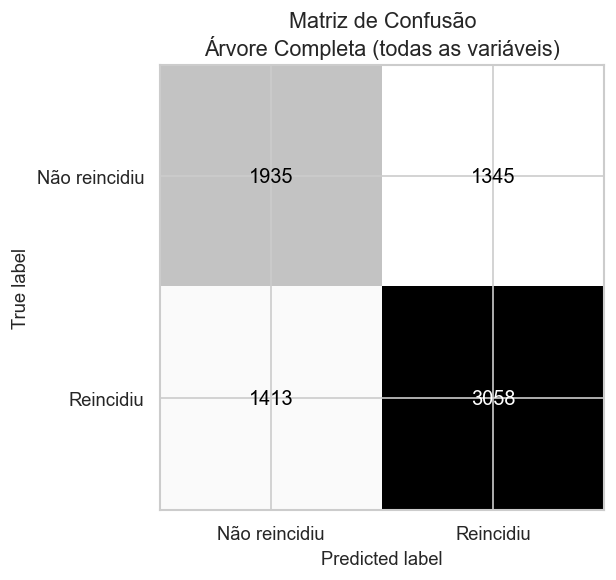


Profundidade da árvore : 30
Número de nós folha    : 3407


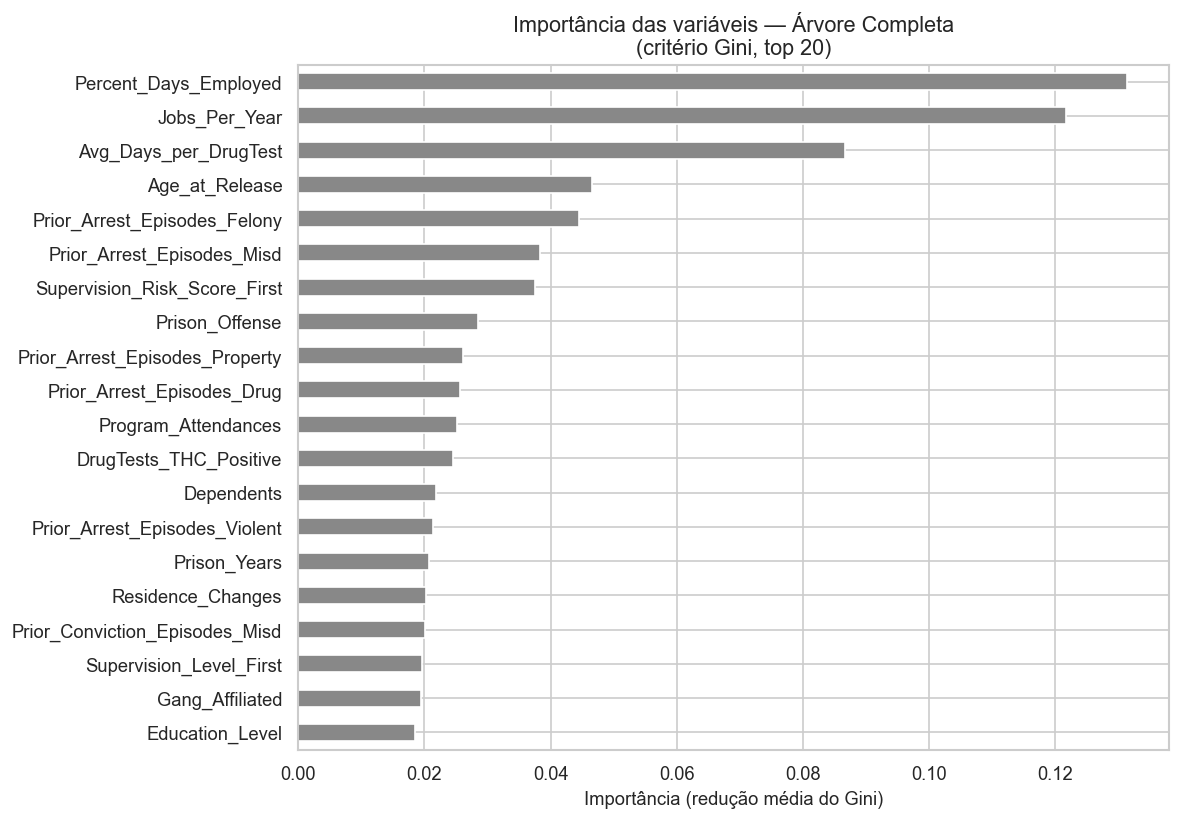


Top 20 variáveis mais importantes (Árvore Completa):
Percent_Days_Employed             0.131395
Jobs_Per_Year                     0.121652
Avg_Days_per_DrugTest             0.086593
Age_at_Release                    0.046502
Prior_Arrest_Episodes_Felony      0.044529
Prior_Arrest_Episodes_Misd        0.038305
Supervision_Risk_Score_First      0.037488
Prison_Offense                    0.028540
Prior_Arrest_Episodes_Property    0.026123
Prior_Arrest_Episodes_Drug        0.025670
Program_Attendances               0.025217
DrugTests_THC_Positive            0.024572
Dependents                        0.021816
Prior_Arrest_Episodes_Violent     0.021326
Prison_Years                      0.020785
Residence_Changes                 0.020209
Prior_Conviction_Episodes_Misd    0.020074
Supervision_Level_First           0.019638
Gang_Affiliated                   0.019527
Education_Level                   0.018585


In [19]:
# Árvore sem restrição de profundidade, modelo completo
dt_completa = DecisionTreeClassifier(
    criterion='gini',
    random_state=SEED
)
dt_completa.fit(X_train, y_train)

metricas_completa = avaliar_modelo(
    'Árvore Completa (todas as variáveis)',
    dt_completa, X_train, y_train, X_test, y_test
)

print(f"\nProfundidade da árvore : {dt_completa.get_depth()}")
print(f"Número de nós folha    : {dt_completa.get_n_leaves()}")

# Importância das variáveis pela árvore completa
imp_completa = plot_importancias(
    dt_completa, FEATURES,
    'Importância das variáveis — Árvore Completa\n(critério Gini, top 20)',
    top_n=20
)

print("\nTop 20 variáveis mais importantes (Árvore Completa):")
print(imp_completa.to_string())

In [20]:

# Selecionar variáveis com importância acima da média
importancia_media = imp_completa.mean()
VARS_SELECIONADAS = imp_completa[imp_completa >= importancia_media].index.tolist()

print(f"Importância média (top 20)     : {importancia_media:.4f}")
print(f"Variáveis selecionadas ({len(VARS_SELECIONADAS)}):")
for v in VARS_SELECIONADAS:
    print(f"  {v:<45}  {imp_completa[v]:.4f}")


Importância média (top 20)     : 0.0399
Variáveis selecionadas (5):
  Percent_Days_Employed                          0.1314
  Jobs_Per_Year                                  0.1217
  Avg_Days_per_DrugTest                          0.0866
  Age_at_Release                                 0.0465
  Prior_Arrest_Episodes_Felony                   0.0445


### Árvore de decisão com variáveis selecionadas


  Árvore com Variáveis Selecionadas (5 vars)
  Acurácia (treino) : 0.9686
  Acurácia (teste)  : 0.6299
  AUC-ROC           : 0.6177

  Relatório de classificação:
                   precision    recall  f1-score   support

Não reincidiu (0)     0.5652    0.5433    0.5540      3280
    Reincidiu (1)     0.6742    0.6934    0.6836      4471

         accuracy                         0.6299      7751
        macro avg     0.6197    0.6183    0.6188      7751
     weighted avg     0.6281    0.6299    0.6288      7751



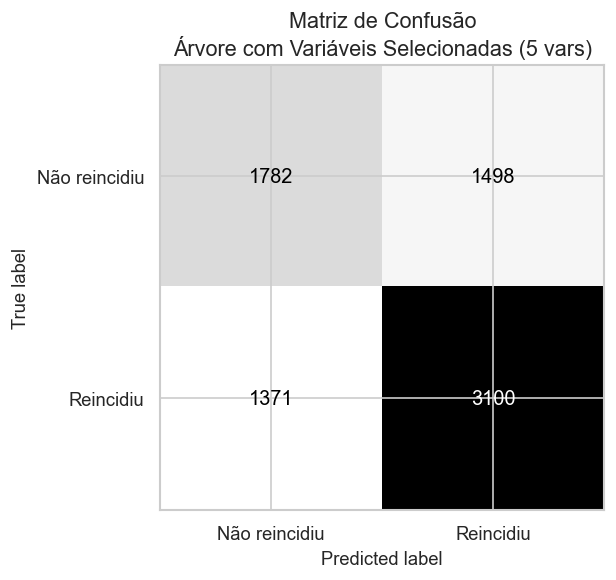


Profundidade da árvore : 43
Número de nós folha    : 4794


In [21]:

X_train_sel = X_train[VARS_SELECIONADAS]
X_test_sel  = X_test[VARS_SELECIONADAS]

dt_selecionada = DecisionTreeClassifier(
    criterion='gini',
    random_state=SEED
)
dt_selecionada.fit(X_train_sel, y_train)

metricas_selecionada = avaliar_modelo(
    f'Árvore com Variáveis Selecionadas ({len(VARS_SELECIONADAS)} vars)',
    dt_selecionada, X_train_sel, y_train, X_test_sel, y_test
)

print(f"\nProfundidade da árvore : {dt_selecionada.get_depth()}")
print(f"Número de nós folha    : {dt_selecionada.get_n_leaves()}")


=== IMPACTO DA PROFUNDIDADE MÁXIMA ===
 max_depth  acuracia_treino  acuracia_teste      auc  n_folhas
         3         0.681099        0.684170 0.702895         8
         4         0.687127        0.681718 0.722932        15
         5         0.702942        0.697071 0.734789        29
         6         0.708140        0.698620 0.744300        56
         7         0.725780        0.704296 0.747902       107
         8         0.733300        0.700297 0.743880       187


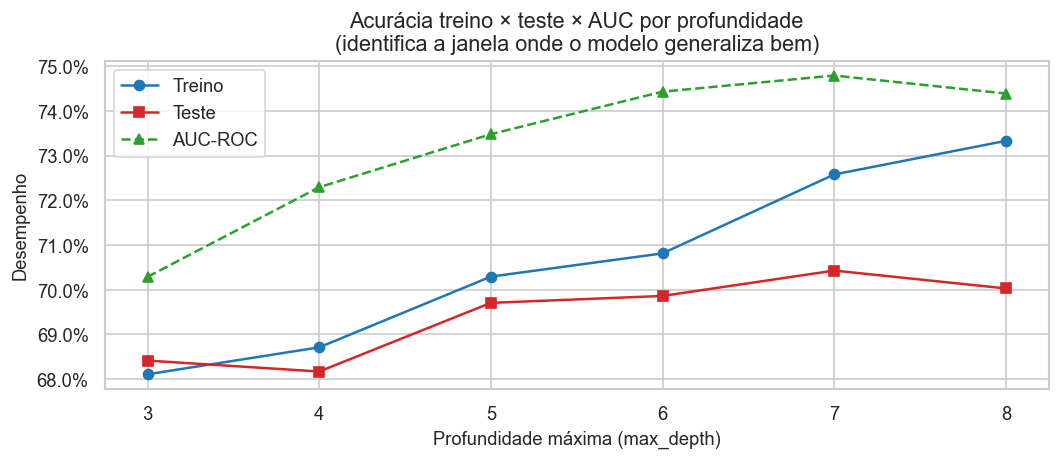

In [22]:
# Árvore PODADA com variáveis selecionadas (para apresentação)
# Árvores sem restrição são profundas demais para visualizar e tendem a
# overfitar. Aqui treinamos versões com profundidade limitada para
# interpretação e apresentação.

resultados_poda = []

for profundidade in [3, 4, 5, 6, 7, 8]:
    dt_pod = DecisionTreeClassifier(
        criterion='gini',
        max_depth=profundidade,
        random_state=SEED
    )
    dt_pod.fit(X_train_sel, y_train)
    y_pred  = dt_pod.predict(X_test_sel)
    y_proba = dt_pod.predict_proba(X_test_sel)[:, 1]
    resultados_poda.append({
        'max_depth':        profundidade,
        'acuracia_treino':  accuracy_score(y_train, dt_pod.predict(X_train_sel)),
        'acuracia_teste':   accuracy_score(y_test,  y_pred),
        'auc':              roc_auc_score(y_test,   y_proba),
        'n_folhas':         dt_pod.get_n_leaves(),
    })

df_poda = pd.DataFrame(resultados_poda)
print("=== IMPACTO DA PROFUNDIDADE MÁXIMA ===")
print(df_poda.to_string(index=False))

# Gráfico acurácia treino vs teste por profundidade
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df_poda['max_depth'], df_poda['acuracia_treino'],
        marker='o', label='Treino', color='#1f77b4')
ax.plot(df_poda['max_depth'], df_poda['acuracia_teste'],
        marker='s', label='Teste',  color='#d62728')
ax.plot(df_poda['max_depth'], df_poda['auc'],
        marker='^', label='AUC-ROC', color='#2ca02c', linestyle='--')
ax.set_xlabel('Profundidade máxima (max_depth)')
ax.set_ylabel('Desempenho')
ax.set_title('Acurácia treino × teste × AUC por profundidade\n'
             '(identifica a janela onde o modelo generaliza bem)')
ax.legend()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()


Melhor profundidade (maior AUC no teste): 7

  Árvore Podada (max_depth=3, 5 vars)
  Acurácia (treino) : 0.6811
  Acurácia (teste)  : 0.6842
  AUC-ROC           : 0.7029

  Relatório de classificação:
                   precision    recall  f1-score   support

Não reincidiu (0)     0.7366    0.3948    0.5141      3280
    Reincidiu (1)     0.6688    0.8964    0.7661      4471

         accuracy                         0.6842      7751
        macro avg     0.7027    0.6456    0.6401      7751
     weighted avg     0.6975    0.6842    0.6594      7751



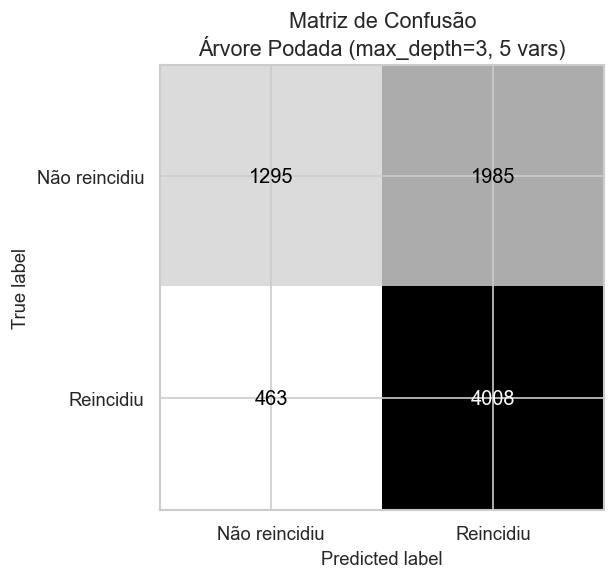

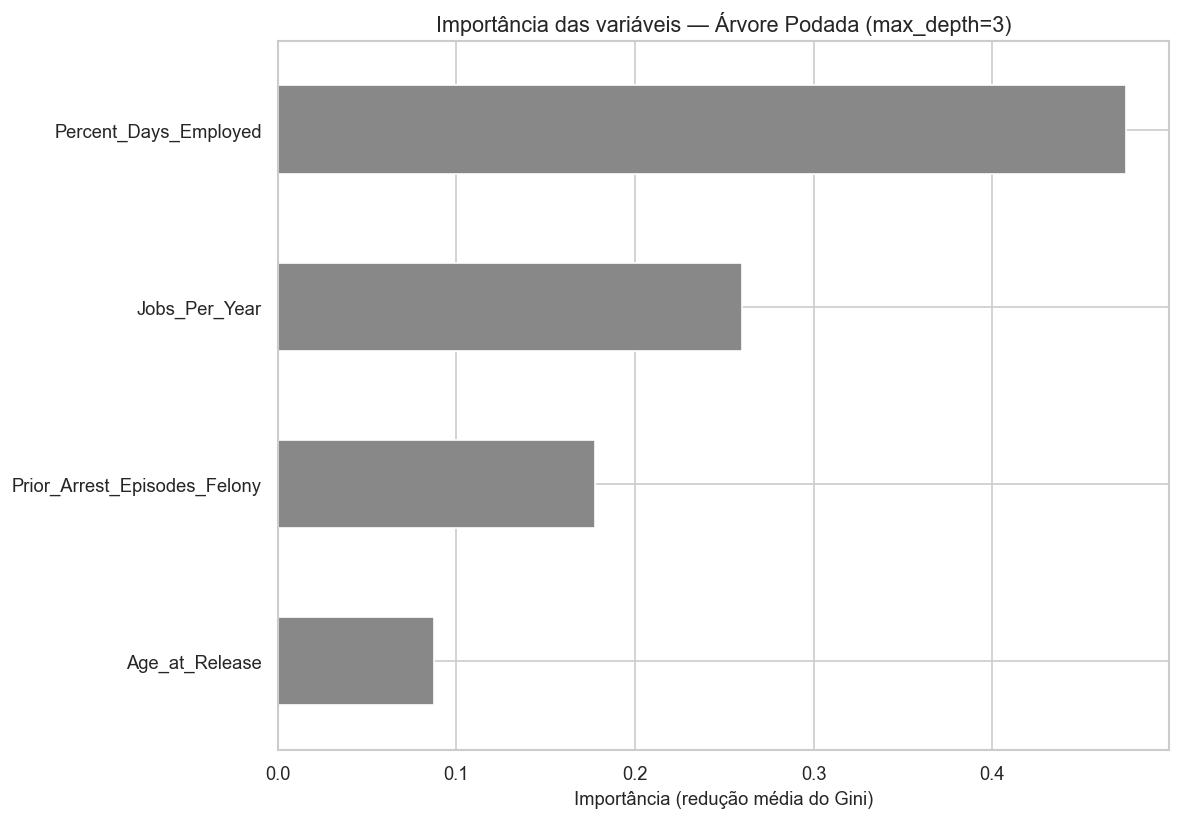

In [35]:
# Escolher a profundidade com maior AUC no teste (critério mais robusto que acurácia)
melhor_depth = df_poda.loc[df_poda['auc'].idxmax(), 'max_depth']
print(f"Melhor profundidade (maior AUC no teste): {melhor_depth}")
# Definindo o melhor deepth manualmente
melhor_depth = 3

dt_podada = DecisionTreeClassifier(
    criterion='gini',
    max_depth=melhor_depth,
    random_state=SEED
)
dt_podada.fit(X_train_sel, y_train)

metricas_podada = avaliar_modelo(
    f'Árvore Podada (max_depth={melhor_depth}, {len(VARS_SELECIONADAS)} vars)',
    dt_podada, X_train_sel, y_train, X_test_sel, y_test
)

# Importância na árvore podada
imp_podada = plot_importancias(
    dt_podada, VARS_SELECIONADAS,
    f'Importância das variáveis — Árvore Podada (max_depth={melhor_depth})'
)

In [36]:
# =============================================================================
# Árvore Podada — Visualização interativa com Plotly (escala de cinza)
# Zoom, pan e hover com informações detalhadas de cada nó
# Use o slider abaixo para controlar a profundidade visível
# =============================================================================

def _layout_arvore(tree, feature_names, max_vis_depth=None):
    """Calcula posições (x, y) dos nós da árvore usando layout tipo 'Reingold-Tilford' simples."""
    feature_names = list(feature_names)
    nos = []
    arestas = []

    def largura_sub(nid, depth):
        """Conta folhas visíveis na subárvore."""
        if tree.children_left[nid] == _tree.TREE_LEAF:
            return 1
        if max_vis_depth is not None and depth >= max_vis_depth:
            return 1
        return (largura_sub(int(tree.children_left[nid]), depth + 1) +
                largura_sub(int(tree.children_right[nid]), depth + 1))

    def posicionar(nid, depth, x_min, x_max):
        n = int(tree.n_node_samples[nid])
        v = tree.value[nid][0]
        total_v = float(v[0] + v[1])
        n_neg = int(round(float(v[0]) / total_v * n))
        n_pos = int(round(float(v[1]) / total_v * n))
        pct = round(n_pos / n * 100, 1) if n > 0 else 0
        gini = round(float(tree.impurity[nid]), 4)
        eh_folha = bool(tree.children_left[nid] == _tree.TREE_LEAF)
        cortada = False

        if not eh_folha and max_vis_depth is not None and depth >= max_vis_depth:
            eh_folha = False
            cortada = True

        x = (x_min + x_max) / 2
        y = -depth

        if eh_folha or cortada:
            if eh_folha:
                pred = 'Reincidiu' if n_pos > n_neg else 'Não reincidiu'
                regra = f'FOLHA → {pred}'
            else:
                feat = feature_names[int(tree.feature[nid])]
                thres = round(float(tree.threshold[nid]), 2)
                regra = f'{feat} ≤ {thres}'

            nos.append(dict(id=nid, x=x, y=y, regra=regra, n=n,
                            n_pos=n_pos, n_neg=n_neg, pct=pct, gini=gini,
                            folha=eh_folha, cortada=cortada, depth=depth))
            return

        feat = feature_names[int(tree.feature[nid])]
        thres = round(float(tree.threshold[nid]), 2)
        regra = f'{feat} ≤ {thres}'

        nos.append(dict(id=nid, x=x, y=y, regra=regra, n=n,
                        n_pos=n_pos, n_neg=n_neg, pct=pct, gini=gini,
                        folha=False, cortada=False, depth=depth))

        left = int(tree.children_left[nid])
        right = int(tree.children_right[nid])
        w_left = largura_sub(left, depth + 1)
        w_right = largura_sub(right, depth + 1)
        w_total = w_left + w_right
        x_split = x_min + (x_max - x_min) * w_left / w_total

        arestas.append((x, y, (x_min + x_split) / 2, -(depth + 1), 'Sim'))
        arestas.append((x, y, (x_split + x_max) / 2, -(depth + 1), 'Não'))

        posicionar(left, depth + 1, x_min, x_split)
        posicionar(right, depth + 1, x_split, x_max)

    posicionar(0, 0, 0, largura_sub(0, 0))
    return nos, arestas


def plotar_arvore_interativa(modelo, feature_names, titulo, max_depth_modelo):
    """Plota árvore interativa com plotly + slider ipywidgets para profundidade."""

    tree = modelo.tree_
    output = widgets.Output()

    def renderizar(depth):
        with output:
            output.clear_output(wait=True)
            nos, arestas = _layout_arvore(tree, feature_names, max_vis_depth=depth)

            fig = go.Figure()

            # Arestas
            for x0, y0, x1, y1, label in arestas:
                fig.add_trace(go.Scatter(
                    x=[x0, x1, None], y=[y0, y1, None],
                    mode='lines',
                    line=dict(color='rgb(160,160,160)', width=1.5),
                    hoverinfo='skip', showlegend=False,
                ))
                # Rótulo da aresta (Sim/Não)
                fig.add_annotation(
                    x=(x0 + x1) / 2, y=(y0 + y1) / 2,
                    text=f'<b>{label}</b>',
                    showarrow=False, font=dict(size=9, color='rgb(100,100,100)'),
                )

            # Nós
            xs = [n['x'] for n in nos]
            ys = [n['y'] for n in nos]
            textos = []
            hovers = []
            cores = []
            bordas = []
            tamanhos = []

            for n in nos:
                if n['folha']:
                    textos.append(f"<b>{n['regra']}</b><br>n={n['n']}")
                    cor = 'rgb(220,220,220)'
                    borda = 'rgb(100,100,100)'
                    tam = 35
                elif n['cortada']:
                    textos.append(f"<b>{n['regra']}</b><br>n={n['n']} [...]")
                    cor = 'rgb(245,245,245)'
                    borda = 'rgb(180,180,180)'
                    tam = 30
                else:
                    textos.append(f"<b>{n['regra']}</b><br>n={n['n']}")
                    cor = 'rgb(240,240,240)'
                    borda = 'rgb(80,80,80)'
                    tam = 30

                hovers.append(
                    f"<b>{n['regra']}</b><br>"
                    f"Amostras: {n['n']}<br>"
                    f"Reincidiu: {n['n_pos']} ({n['pct']}%)<br>"
                    f"Não reincidiu: {n['n_neg']} ({round(100-n['pct'],1)}%)<br>"
                    f"Gini: {n['gini']}<br>"
                    f"Profundidade: {n['depth']}"
                )
                cores.append(cor)
                bordas.append(borda)
                tamanhos.append(tam)

            fig.add_trace(go.Scatter(
                x=xs, y=ys,
                mode='markers+text',
                marker=dict(
                    size=tamanhos,
                    color=cores,
                    line=dict(width=2, color=bordas),
                    symbol='square',
                ),
                text=textos,
                textposition='top center',
                textfont=dict(size=8),
                hovertext=hovers,
                hoverinfo='text',
                hoverlabel=dict(bgcolor='white', font_size=11),
                showlegend=False,
            ))

            fig.update_layout(
                title=f'{titulo}<br><sub>Profundidade visível: {depth} | Zoom e arraste para navegar</sub>',
                xaxis=dict(showgrid=False, zeroline=False, showticklabels=False, title=''),
                yaxis=dict(showgrid=False, zeroline=False, showticklabels=False, title=''),
                template='plotly_white',
                width=1100,
                height=max(500, depth * 150),
                dragmode='pan',
            )
            fig.show(config={'scrollZoom': True, 'displayModeBar': True})

    slider = widgets.IntSlider(
        value=min(3, max_depth_modelo),
        min=1, max=max_depth_modelo,
        step=1, description='Profundidade:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='500px'),
    )

    widgets.interactive_output(renderizar, {'depth': slider})
    display(slider, output)
    renderizar(slider.value)


# --- Plotar árvore podada interativa ---
plotar_arvore_interativa(
    modelo=dt_podada,
    feature_names=VARS_SELECIONADAS,
    titulo=f'Árvore de Decisão Podada (max_depth={melhor_depth})',
    max_depth_modelo=int(dt_podada.get_depth()),
)

# # Versão texto da árvore (útil para relatórios)
# print("\n=== ESTRUTURA DA ÁRVORE (texto) ===")
# print(export_text(dt_podada, feature_names=VARS_SELECIONADAS, max_depth=3))

IntSlider(value=3, description='Profundidade:', layout=Layout(width='500px'), max=3, min=1, style=SliderStyle(…

Output()

=== COMPARATIVO FINAL ===
                                       Acurácia Treino  Acurácia Teste  AUC-ROC
Modelo                                                                         
Árvore Completa (todas as vars)                 1.0000          0.6442   0.6370
Árvore Selecionada (5 vars, sem poda)           0.9686          0.6299   0.6177
Árvore Podada (max_depth=3)                     0.6811          0.6842   0.7029


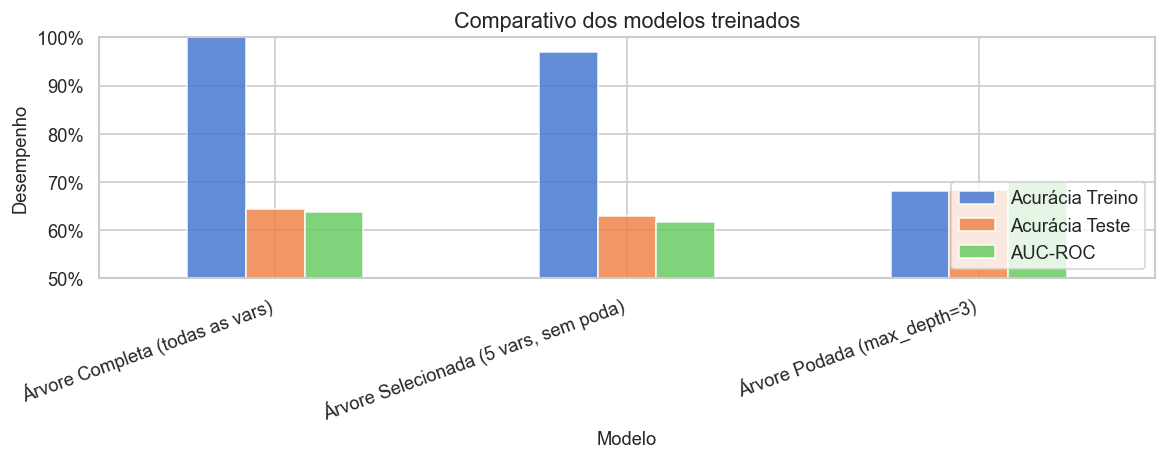

In [37]:

df_comparativo = pd.DataFrame([
    {'Modelo': 'Árvore Completa (todas as vars)',
     **metricas_completa},
    {'Modelo': f'Árvore Selecionada ({len(VARS_SELECIONADAS)} vars, sem poda)',
     **metricas_selecionada},
    {'Modelo': f'Árvore Podada (max_depth={melhor_depth})',
     **metricas_podada},
]).set_index('Modelo')

df_comparativo.columns = ['Acurácia Treino', 'Acurácia Teste', 'AUC-ROC']
print("=== COMPARATIVO FINAL ===")
print(df_comparativo.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
df_comparativo.plot(kind='bar', ax=ax, edgecolor='white', alpha=0.85)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Desempenho')
ax.set_title('Comparativo dos modelos treinados')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.legend(loc='lower right')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

In [38]:
# =============================================================================
# Árvore COMPLETA interativa (max_depth=5 para visualização)
# Escala de cinza, com slider de profundidade e hover detalhado
# =============================================================================

dt_completa_viz = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=SEED
)
dt_completa_viz.fit(X_train, y_train)

plotar_arvore_interativa(
    modelo=dt_completa_viz,
    feature_names=FEATURES,
    titulo='Árvore Completa — Todas as Variáveis (max_depth=5)',
    max_depth_modelo=int(dt_completa_viz.get_depth()),
)

IntSlider(value=3, description='Profundidade:', layout=Layout(width='500px'), max=5, min=1, style=SliderStyle(…

Output()

In [39]:
# =============================================================================
# Árvores interativas HTML (D3.js) — responsivas, clicáveis, escala de cinza
# Clique em qualquer nó para expandir/colapsar seus filhos
# Layout ocupa 100% da tela do navegador com botão "Ajustar à tela"
# =============================================================================

import json
from IPython.display import IFrame, display as ipy_display


def tree_para_json(modelo, feature_names, classe_alvo_nome='Reincidência'):
    """Converte árvore sklearn em dicionário JSON para D3."""
    tree = modelo.tree_
    feature_names = list(feature_names)

    def construir_no(nid):
        n = int(tree.n_node_samples[nid])
        v = tree.value[nid][0]
        total_v = float(v[0] + v[1])
        n_neg = int(round(float(v[0]) / total_v * n))
        n_pos = int(round(float(v[1]) / total_v * n))
        pct = round(n_pos / n * 100, 1)
        gini = round(float(tree.impurity[nid]), 4)
        eh_folha = bool(tree.children_left[nid] == _tree.TREE_LEAF)

        if eh_folha:
            regra = 'Folha'
            pred = 'Reincidiu' if n_pos > n_neg else 'Não reincidiu'
        else:
            feat = feature_names[int(tree.feature[nid])]
            thres = round(float(tree.threshold[nid]), 3)
            regra = f'{feat} \u2264 {thres}'
            pred = None

        no = dict(id=int(nid), regra=str(regra), n=n,
                  n_pos=n_pos, n_neg=n_neg, pct=pct, gini=gini,
                  folha=eh_folha,
                  pred=str(pred) if pred else None,
                  classe_alvo=str(classe_alvo_nome))

        if not eh_folha:
            esq = int(tree.children_left[nid])
            dir_ = int(tree.children_right[nid])
            no['children'] = [construir_no(esq), construir_no(dir_)]
            no['children'][0]['lado'] = 'sim'
            no['children'][1]['lado'] = 'nao'
        return no

    return construir_no(0)


def gerar_arvore_html(modelo, feature_names,
                      titulo='Árvore de Decisão Interativa',
                      classe_alvo_nome='Reincidência',
                      arquivo='arvore_interativa.html'):
    tree_json_str = json.dumps(
        tree_para_json(modelo, feature_names, classe_alvo_nome),
        ensure_ascii=False
    )

    html = '<!DOCTYPE html>\n'
    html += '<html lang="pt-BR">\n<head>\n<meta charset="UTF-8">\n'
    html += '<meta name="viewport" content="width=device-width, initial-scale=1.0">\n'
    html += f'<title>{titulo}</title>\n'
    html += '<script src="https://cdnjs.cloudflare.com/ajax/libs/d3/7.8.5/d3.min.js"></script>\n'
    html += """<style>
*{margin:0;padding:0;box-sizing:border-box;}
html,body{width:100%;height:100%;overflow:hidden;font-family:'Segoe UI',Arial,sans-serif;background:#fafafa;}
.app{display:flex;flex-direction:column;width:100vw;height:100vh;}
#header{background:#333;color:white;padding:10px 20px;font-size:15px;font-weight:bold;
        display:flex;justify-content:space-between;align-items:center;flex-shrink:0;}
#legend{background:#f5f5f5;padding:6px 20px;font-size:11px;border-bottom:1px solid #ddd;
        display:flex;gap:16px;align-items:center;flex-wrap:wrap;flex-shrink:0;}
.leg-item{display:flex;align-items:center;gap:5px;}
.leg-box{width:14px;height:14px;border-radius:2px;border:1px solid #999;flex-shrink:0;}
#controls{background:#f5f5f5;padding:6px 20px;font-size:12px;border-bottom:1px solid #ddd;
          display:flex;gap:10px;align-items:center;flex-shrink:0;}
button{padding:4px 10px;border:1px solid #aaa;border-radius:3px;cursor:pointer;
       background:#eee;font-size:11px;}
button:hover{background:#ddd;}
#tree-container{flex:1;width:100%;overflow:hidden;position:relative;}
svg{width:100%;height:100%;display:block;cursor:grab;}
svg:active{cursor:grabbing;}
.link{fill:none;stroke:#bbb;stroke-width:1.8px;}
.link-label{font-size:10px;font-style:italic;font-weight:bold;}
.node rect{cursor:pointer;transition:stroke-width 0.15s;}
.node rect:hover{stroke-width:3px;stroke:#333;}
.node text{pointer-events:none;}
.node-folha>rect:first-child{stroke-dasharray:5,3;}
.node-collapsed>rect:first-child{stroke:#555;stroke-width:2.5px;}
</style>
</head>
<body>
<div class="app">
"""
    html += f'<div id="header"><span>{titulo}</span>'
    html += '<span style="font-size:11px;font-weight:normal;color:#ccc;">Escala de cinza | Clique nos n\u00f3s para expandir/colapsar</span></div>\n'
    html += """<div id="legend">
  <div class="leg-item"><div class="leg-box" style="background:#444"></div>Gini&asymp;0 (puro)</div>
  <div class="leg-item"><div class="leg-box" style="background:#999"></div>Gini&asymp;0.25</div>
  <div class="leg-item"><div class="leg-box" style="background:#ddd"></div>Gini&asymp;0.5 (m&aacute;x)</div>
  <div class="leg-item"><div class="leg-box" style="background:white;border:2px dashed #666;"></div>Folha</div>
  <div class="leg-item"><div class="leg-box" style="background:#eee;border:2.5px solid #555;"></div>Colapsado</div>
</div>
<div id="controls">
  <button onclick="expandAll()">&#9660; Expandir tudo</button>
  <button onclick="collapseAll()">&#9650; Colapsar tudo</button>
  <button onclick="resetZoom()">&#8635; Resetar zoom</button>
  <button onclick="fitToScreen()">&#8862; Ajustar &agrave; tela</button>
  <span style="color:#888;font-size:10px;">Scroll=zoom | Arraste=mover | Clique=expandir/colapsar</span>
</div>
<div id="tree-container"></div>
</div>
<script>
"""
    html += f'const DATA={tree_json_str};\n'
    html += """const NODE_W=220,NODE_H=92,H_GAP=24,V_GAP=50;

function giniCor(g){
  var t=Math.min(g/0.5,1);
  var v=Math.round(68+(221-68)*t);
  return 'rgb('+v+','+v+','+v+')';
}
function headerCor(g){
  var t=Math.min(g/0.5,1);
  var v=Math.max(0,Math.round(68+(221-68)*t)-25);
  return 'rgb('+v+','+v+','+v+')';
}
function textCor(g){return g<0.35?'white':'#111';}

var collapsed=new Set();

function cloneTree(d){
  var n=Object.assign({},d);
  if(d.children&&!collapsed.has(d.id)){
    n.children=d.children.map(cloneTree);
  }else{
    n._kids=d.children||d._kids||null;
    n.children=null;
  }
  return n;
}

var container=document.getElementById('tree-container');
var svg=d3.select('#tree-container').append('svg');
var gEl=svg.append('g');
var zoomBehavior=d3.zoom().scaleExtent([0.05,4]).on('zoom',function(e){gEl.attr('transform',e.transform);});
svg.call(zoomBehavior);

function resetZoom(){svg.transition().duration(400).call(zoomBehavior.transform,d3.zoomIdentity.translate(60,40).scale(0.8));}

function fitToScreen(){
  var bounds=gEl.node().getBBox();
  if(!bounds.width)return;
  var cw=container.clientWidth,ch=container.clientHeight;
  var scale=Math.min(cw/(bounds.width+80),ch/(bounds.height+80),1.5);
  var tx=cw/2-(bounds.x+bounds.width/2)*scale;
  var ty=ch/2-(bounds.y+bounds.height/2)*scale;
  svg.transition().duration(500).call(zoomBehavior.transform,
    d3.zoomIdentity.translate(tx,ty).scale(scale));
}

function render(){
  gEl.selectAll('*').remove();
  var root=d3.hierarchy(cloneTree(DATA),function(d){return d.children;});
  d3.tree().nodeSize([NODE_W+H_GAP,NODE_H+V_GAP])(root);

  var descs=root.descendants();
  var xs=descs.map(function(d){return d.x;}),ys=descs.map(function(d){return d.y;});
  var minX=Math.min.apply(null,xs)-NODE_W/2-30,maxX=Math.max.apply(null,xs)+NODE_W/2+30;
  var minY=Math.min.apply(null,ys)-30,maxY=Math.max.apply(null,ys)+NODE_H+30;
  var ox=-minX+10,oy=-minY+10;

  gEl.selectAll('.link').data(root.links()).join('path').attr('class','link')
    .attr('d',function(d){
      var sx=d.source.x+ox,sy=d.source.y+NODE_H+oy;
      var tx=d.target.x+ox,ty=d.target.y+oy;
      var my=(sy+ty)/2;
      return 'M'+sx+','+sy+' C'+sx+','+my+' '+tx+','+my+' '+tx+','+ty;
    });

  gEl.selectAll('.link-label').data(root.links()).join('text').attr('class','link-label')
    .attr('x',function(d){return(d.source.x+d.target.x)/2+ox+(d.target.data.lado==='sim'?-16:16);})
    .attr('y',function(d){return(d.source.y+NODE_H+d.target.y)/2+oy;})
    .attr('text-anchor','middle')
    .attr('fill',function(d){return d.target.data.lado==='sim'?'#555':'#888';})
    .text(function(d){return d.target.data.lado==='sim'?'Sim':'N\\u00e3o';});

  var nodes=gEl.selectAll('.node').data(descs).join('g')
    .attr('class',function(d){
      var c='node';
      if(d.data.folha)c+=' node-folha';
      if(!d.data.folha&&collapsed.has(d.data.id))c+=' node-collapsed';
      return c;
    })
    .attr('transform',function(d){return 'translate('+(d.x+ox-NODE_W/2)+','+(d.y+oy)+')';});

  nodes.append('rect')
    .attr('width',NODE_W).attr('height',NODE_H).attr('rx',6).attr('ry',6)
    .attr('fill',function(d){return giniCor(d.data.gini);})
    .attr('stroke','#777').attr('stroke-width',1.5)
    .on('click',function(ev,d){
      ev.stopPropagation();
      if(d.data.folha)return;
      if(collapsed.has(d.data.id)){collapsed.delete(d.data.id);}else{collapsed.add(d.data.id);}
      render();
    });

  nodes.filter(function(d){return !d.data.folha;}).append('rect')
    .attr('width',NODE_W).attr('height',24).attr('rx',6).attr('ry',6)
    .attr('fill',function(d){return headerCor(d.data.gini);}).style('pointer-events','none');

  nodes.append('line')
    .attr('x1',0).attr('x2',NODE_W).attr('y1',24).attr('y2',24)
    .attr('stroke','rgba(0,0,0,0.1)').attr('stroke-width',1)
    .style('pointer-events','none');

  nodes.append('text')
    .attr('x',NODE_W/2).attr('y',16).attr('text-anchor','middle')
    .attr('font-size',10).attr('font-weight','bold')
    .attr('fill',function(d){return textCor(d.data.gini);})
    .text(function(d){return d.data.regra.length>28?d.data.regra.slice(0,27)+'\\u2026':d.data.regra;})
    .append('title').text(function(d){return d.data.regra;});

  nodes.append('text')
    .attr('x',NODE_W/2).attr('y',44).attr('text-anchor','middle')
    .attr('font-size',13).attr('font-weight','bold')
    .attr('fill',function(d){return textCor(d.data.gini);})
    .text(function(d){return '% Reincid\\u00eancia: '+d.data.pct+'%';});

  nodes.append('text')
    .attr('x',NODE_W/2).attr('y',60).attr('text-anchor','middle')
    .attr('font-size',9).attr('fill',function(d){return textCor(d.data.gini);})
    .text(function(d){return 'n = '+d.data.n.toLocaleString('pt-BR')+'   Gini = '+d.data.gini;});

  nodes.filter(function(d){return d.data.folha;}).append('text')
    .attr('x',NODE_W/2).attr('y',78).attr('text-anchor','middle')
    .attr('font-size',10).attr('font-weight','bold')
    .attr('fill',function(d){return textCor(d.data.gini);})
    .text(function(d){return '\\u2192 '+d.data.pred;});

  nodes.filter(function(d){return !d.data.folha;}).append('text')
    .attr('x',NODE_W/2).attr('y',78).attr('text-anchor','middle')
    .attr('font-size',9).attr('fill',function(d){return textCor(d.data.gini);})
    .text(function(d){return collapsed.has(d.data.id)?'\\u25b6 clique para expandir':'\\u25c0 clique para colapsar';});
}

function expandAll(){collapsed.clear();render();setTimeout(fitToScreen,100);}
function collapseAll(){
  function col(d){if(d.children){collapsed.add(d.id);d.children.forEach(col);}}
  if(DATA.children)DATA.children.forEach(col);
  render();setTimeout(fitToScreen,100);
}

render();
setTimeout(fitToScreen,200);
window.addEventListener('resize',function(){setTimeout(fitToScreen,100);});
</script>
</body>
</html>"""

    with open(arquivo, 'w', encoding='utf-8') as f:
        f.write(html)
    print(f"\u2713 Árvore salva em '{arquivo}' — abra no navegador para interagir.")
    ipy_display(IFrame(src=arquivo, width='100%', height=700))


# --- Gerar árvore podada ---
gerar_arvore_html(
    modelo=dt_podada,
    feature_names=VARS_SELECIONADAS,
    titulo=f'Árvore Podada — Variáveis Selecionadas (max_depth={melhor_depth})',
    classe_alvo_nome='Reincidência',
    arquivo='arvore_podada_interativa.html',
)

# --- Gerar árvore completa (max_depth=5) ---
gerar_arvore_html(
    modelo=dt_completa_viz,
    feature_names=FEATURES,
    titulo='Árvore Completa — Todas as Variáveis (max_depth=5)',
    classe_alvo_nome='Reincidência',
    arquivo='arvore_completa_interativa.html',
)

✓ Árvore salva em 'arvore_podada_interativa.html' — abra no navegador para interagir.


✓ Árvore salva em 'arvore_completa_interativa.html' — abra no navegador para interagir.
